# **Regression Model Training Notebook**



---
## 0. Setup Environment

### 0.a Install Mandatory Packages

> Do not modify this code before running it

In [1]:
# Do not modify this code

import os
import sys
from pathlib import Path

COURSE = "36106"
ASSIGNMENT = "AT3"
DATA = "data"

asgmt_path = f"{COURSE}/assignment/{ASSIGNMENT}"
root_path = "./"

#print("###### Install required Python packages ######")
! pip install -q -r https://raw.githubusercontent.com/aso-uts/labs_datasets/main/36106-mlaa/requirements.txt

if os.getenv("COLAB_RELEASE_TAG"):

    from google.colab import drive
    from pathlib import Path

    #print("\n###### Connect to personal Google Drive ######")
    gdrive_path = "/content/gdrive"
    drive.mount(gdrive_path)
    root_path = f"{gdrive_path}/MyDrive/"

print("\n###### Setting up folders ######")
folder_path = Path(f"{root_path}/{asgmt_path}/") / DATA
folder_path.mkdir(parents=True, exist_ok=True)
print(f"\nYou can now save your data files in: {folder_path}")

if os.getenv("COLAB_RELEASE_TAG"):
    %cd {folder_path}

from IPython.display import display, HTML

def print_tile(key, value, size="h1"):
  return display(HTML(f"""<p style="color:grey">{key}</p><{size} font-size: 3em>{value}</{size}>"""))

Mounted at /content/gdrive

###### Setting up folders ######

You can now save your data files in: /content/gdrive/MyDrive/36106/assignment/AT3/data
/content/gdrive/MyDrive/36106/assignment/AT3/data


### 0.b Disable Warnings Messages

> Do not modify this code before running it

In [2]:
# Do not modify this code
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

### 0.c Install Additional Packages

> If you are using additional packages, you need to install them here using the command: `! pip install <package_name>`

In [ ]:
# <Student to fill this section>

### 0.d Import Packages

In [3]:
# <Student to fill this section>
import pandas as pd
import altair as alt

---
## A. Project Description


In [4]:
# <Student to fill this section>
group_name = "Group 24"
student_name = "Philopatir Bebawy"
student_id = "24647024"

In [5]:
# Do not modify this code
print_tile(size="h1", key='group_name', value=group_name)

In [6]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [7]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

---
## B. Business Understanding

In [16]:
# <Student to fill this section>
business_use_case_description = """
The primary business objective is to empower the Customer Support team to proactively identify and engage with customers exhibiting abnormal spending or usage patterns. These anomalies could manifest as sudden spikes or drops in service consumption, deviations from historical spending habits, or unusual subscription activities compared to their peers or past behavior.

Identifying such anomalies is crucial for several reasons:
1.  Fraud Detection: Unusual activity can be an early indicator of fraudulent account use or compromised credentials.
2.  Customer Retention: Customers unknowingly overspending due to misunderstanding service tiers or unexpected usage may become dissatisfied and churn. Conversely, a sudden drop in usage might signal disengagement or technical issues.
3.  Proactive Support & Billing Clarity: Reaching out to customers with anomalous patterns can help clarify billing, address potential service issues, or offer more suitable plans, thereby enhancing customer satisfaction and trust.
4.  Service & System Integrity: Some anomalies might point towards issues in service provisioning, feature malfunction, or billing system errors.
5.  Resource Optimization: By focusing support efforts on these flagged customers, the team can allocate resources more effectively, potentially preventing larger issues down the line.

This project aims to develop an anomaly detection model using customer usage, subscription, and demographic data. The model will flag customers whose patterns deviate significantly from the norm (either their own historical baseline or that of similar customer segments). This will enable the Customer Support team to initiate timely and targeted interventions, ultimately aiming to reduce fraud-related losses, mitigate customer churn, improve overall customer satisfaction, and ensure fair billing practices.
"""

In [17]:
# Do not modify this code
print_tile(size="h3", key='business_use_case_description', value=business_use_case_description)

In [18]:
# <Student to fill this section>
business_objectives = """
The key business objectives for implementing an anomaly detection system for customer spending patterns are:

1.  Reduce Financial Losses from Fraud:** To decrease financial losses attributed to fraudulent account activity by enabling quicker identification and mitigation of suspicious patterns.
2.  Decrease Customer Churn:** To lower the rate of customer churn resulting from billing misunderstandings or unaddressed service issues by proactively identifying and resolving anomalous usage or spending.
3.  Improve Customer Satisfaction:** To enhance customer satisfaction and trust by offering timely support and clarification to customers experiencing unusual spending or service usage, leading to a better overall customer experience.
4.  Enhance Operational Efficiency:** To optimize the allocation of Customer Support resources by automatically flagging accounts that require attention, allowing the team to focus on high-impact interventions.
5.  Increase Service Integrity and Billing Accuracy:** To identify and address potential flaws or errors in service delivery or billing systems that manifest as anomalous customer data, thereby improving system reliability and fairness.
"""

In [19]:
# Do not modify this code
print_tile(size="h3", key='business_objectives', value=business_objectives)

In [20]:
# <Student to fill this section>
stakeholders_expectations_explanations = """
Several stakeholders will have specific expectations regarding the outcomes and functionality of this anomaly detection project:

1.  Customer Support Team (Managers and Agents):
    Expectation: A reliable, intuitive tool or alert system that accurately identifies customers with genuinely abnormal spending/usage patterns.
    Explanation: They need actionable insights with clear reasons for why an account is flagged, enabling them to prioritize outreach efficiently. They expect the system to reduce false positives (flagging normal customers) and false negatives (missing actual anomalies) to make their interventions effective and build trust in the system. They also hope it will provide sufficient context for them to address customer issues promptly.

2.  **Finance Department / Fraud Prevention Team:
    Expectation: A measurable reduction in financial losses due to fraud and significant billing errors.
    Explanation: They anticipate the system will serve as an early warning mechanism for potentially fraudulent activities or costly billing discrepancies, contributing directly to protecting revenue and company assets. They'll be interested in metrics related to prevented losses.

3.  Customers:
    Expectation: Fair and accurate billing, proactive and helpful support when issues arise, and the security of their accounts and personal information.
    Explanation: While indirect users, customers are key stakeholders. They expect the service provider to act responsibly. If their spending is unusual, they might appreciate proactive outreach if it helps them avoid bill shock or signals a compromised account. The system should ideally contribute to a more trustworthy and supportive customer experience, not cause undue alarm.

4.  Management / Leadership (e.g., Head of Customer Operations, Head of Product, COO):
    Expectation: Demonstrable positive impact on key business metrics such as reduced customer churn, lower operational costs (e.g., in fraud resolution), improved customer satisfaction (e.g., NPS/CSAT), and overall risk mitigation.
    Explanation: Leadership will look for a clear return on investment (ROI). They expect the anomaly detection system to contribute to strategic goals like enhancing customer loyalty, optimizing resources, and ensuring business integrity. They will want regular reports on performance and business impact.

5.  Data Science / Analytics Team (Your Team):
    Expectation: Successful development, validation, and potential deployment of an effective anomaly detection model that meets the defined business objectives.
    Explanation: The team is expected to deliver a technically robust solution, communicate its capabilities and limitations clearly, and provide insights that can inform business decisions. There's also an expectation of maintaining and potentially improving the model over time.

6.  IT / Engineering Team:
    Expectation: If the model is to be productionized, they expect a solution that is scalable, maintainable, and can be integrated with existing operational systems and workflows with reasonable effort.
    Explanation: They will be concerned with the technical aspects of deployment, such as performance, stability, data pipeline dependencies, and monitoring requirements.
"""

In [21]:
# Do not modify this code
print_tile(size="h3", key='stakeholders_expectations_explanations', value=stakeholders_expectations_explanations)

---
## C. Data Understanding

### C.1   Load Datasets

In [25]:
import pandas as pd

file_satisfaction = '/content/customer_satisfaction_clean.csv'
file_subscriptions = '/content/df_eng_customer_subscriptions.csv'
file_usage = '/content/engineered_customer_usage.csv'
file_details = '/content/df_eng_customer_details.csv'
file_address = '/content/customer_address_clean.csv'

try:
    df_satisfaction = pd.read_csv(file_satisfaction)
    df_subscriptions = pd.read_csv(file_subscriptions)
    df_usage = pd.read_csv(file_usage)
    df_details = pd.read_csv(file_details)
    df_address = pd.read_csv(file_address)

    print(f"Successfully loaded '{file_satisfaction}'")
    print(f"DataFrame 'df_satisfaction' shape: {df_satisfaction.shape}")
    print(f"Successfully loaded '{file_subscriptions}'")
    print(f"DataFrame 'df_subscriptions' shape: {df_subscriptions.shape}")
    print(f"Successfully loaded '{file_usage}'")
    print(f"DataFrame 'df_usage' shape: {df_usage.shape}")
    print(f"Successfully loaded '{file_details}'")
    print(f"DataFrame 'df_details' shape: {df_details.shape}")
    print(f"Successfully loaded '{file_address}'")
    print(f"DataFrame 'df_address' shape: {df_address.shape}")

    print("\n--- First 5 rows of df_satisfaction ---")
    print(df_satisfaction.head())
    print("\n--- First 5 rows of df_subscriptions ---")
    print(df_subscriptions.head())
    print("\n--- First 5 rows of df_usage ---")
    print(df_usage.head())
    print("\n--- First 5 rows of df_details ---")
    print(df_details.head())
    print("\n--- First 5 rows of df_address ---")
    print(df_address.head())

except FileNotFoundError as e:
    print(f"Error: {e}. Please ensure all CSV files are in the '/content/' directory of your Colab environment.")
    print("You can check the exact file paths in the Colab file explorer on the left panel.")
except Exception as e:
    print(f"An error occurred: {e}")

Successfully loaded '/content/customer_satisfaction_clean.csv'
DataFrame 'df_satisfaction' shape: (7043, 6)
Successfully loaded '/content/df_eng_customer_subscriptions.csv'
DataFrame 'df_subscriptions' shape: (12081, 22)
Successfully loaded '/content/engineered_customer_usage.csv'
DataFrame 'df_usage' shape: (11125, 13)
Successfully loaded '/content/df_eng_customer_details.csv'
DataFrame 'df_details' shape: (8730, 11)
Successfully loaded '/content/customer_address_clean.csv'
DataFrame 'df_address' shape: (6338, 7)

--- First 5 rows of df_satisfaction ---
   Unnamed: 0                           customer_id  nps  cltv reason  churned
0           0  70f18737-5835-4639-be44-f1a8c6604490    4  2056    NaN        0
1           1  206e8726-2743-4739-8f2f-758e30256314    3  2916    NaN        0
2           2  40da1c87-0650-4378-b8d7-0a49cb21085c    4  5248    NaN        0
3           3  4e28bb69-cee2-4fdf-8831-28935bb5e9b6    3  4607    NaN        0
4           4  39c9339b-c22b-4bf2-8c73-deb7b

### C.2 Define Target variable

In [26]:
# <Student to fill this section>
target_definition_explanations = """
In this anomaly detection project, the **target variable is not an explicit, pre-existing column in the datasets**. Instead, it is a **conceptual label** we aim to assign to each customer (or customer observation period) indicating whether their spending and/or usage pattern is considered 'normal' or 'anomalous'.

Definition of an Anomaly (Our Target Concept):
An 'anomaly' will represent a customer whose spending patterns or service usage metrics deviate significantly from:
1.  Their own historical behavior (e.g., a sudden, uncharacteristic spike in data usage for a usually low-usage customer).
2.  The typical behavior of their peer group or segment (e.g., a customer on a basic plan suddenly exhibiting usage patterns typical of premium users, or vice-versa).
3.  Predefined business rules or thresholds if applicable (though the primary approach will be data-driven).

Representation:
The outcome of our anomaly detection model will effectively create this target. It might be:
A binary flag (e.g., 1 for anomalous, 0 for normal).
An anomaly score (a continuous value where higher scores indicate a higher likelihood of being an anomaly). For practical intervention, these scores would typically be thresholded to produce a binary flag.

Data Sources for Identifying the Target:
The primary data sources for identifying these anomalous patterns will be:
`engineered_customer_usage.csv`: Contains key metrics like data usage, call minutes, services consumed, etc., which are central to defining "spending patterns."
`df_eng_customer_subscriptions.csv`: Provides context about the customer's subscribed plan, costs, and tenure, which helps in determining if usage is anomalous relative to their subscription.

Rationale:
This definition aligns with the business use case of "Helping Customer Support team to reach out to customers with abnormal spending patterns." The goal is to flag patterns that are unexpected and potentially problematic (indicating fraud, bill shock risk, customer dissatisfaction, or service issues), thus warranting proactive intervention from the Customer Support team.

Since this is primarily an unsupervised anomaly detection task, we are not starting with known anomalies. The model's purpose is to discover these instances from the data.
"""

In [27]:
# Do not modify this code
print_tile(size="h3", key='target_definition_explanations', value=target_definition_explanations)

### C.3 Create Target variable

In [30]:
# <Student to fill this section>

file_satisfaction = '/content/customer_satisfaction_clean.csv'
file_subscriptions = '/content/df_eng_customer_subscriptions.csv'
file_usage = '/content/engineered_customer_usage.csv'
file_details = '/content/df_eng_customer_details.csv'
file_address = '/content/customer_address_clean.csv'

dataframes = {}
loaded_successfully = True

try:
    print("Loading datasets...")
    dataframes['df_satisfaction'] = pd.read_csv(file_satisfaction)
    print(f"Successfully loaded '{file_satisfaction}' into dataframes['df_satisfaction']")
    print(f"Shape: {dataframes['df_satisfaction'].shape}")

    dataframes['df_subscriptions'] = pd.read_csv(file_subscriptions)
    print(f"Successfully loaded '{file_subscriptions}' into dataframes['df_subscriptions']")
    print(f"Shape: {dataframes['df_subscriptions'].shape}")

    dataframes['df_usage'] = pd.read_csv(file_usage)
    print(f"Successfully loaded '{file_usage}' into dataframes['df_usage']")
    print(f"Shape: {dataframes['df_usage'].shape}")

    dataframes['df_details'] = pd.read_csv(file_details)
    print(f"Successfully loaded '{file_details}' into dataframes['df_details']")
    print(f"Shape: {dataframes['df_details'].shape}")

    dataframes['df_address'] = pd.read_csv(file_address)
    print(f"Successfully loaded '{file_address}' into dataframes['df_address']")
    print(f"Shape: {dataframes['df_address'].shape}")

    print("\n--- Info for dataframes['df_usage']")
    dataframes['df_usage'].info()
    print("\n--- First 5 rows of dataframes['df_usage']")
    print(dataframes['df_usage'].head())

    print("\n--- Info for dataframes['df_subscriptions']")
    dataframes['df_subscriptions'].info()
    print("\n--- First 5 rows of dataframes['df_subscriptions']")
    print(dataframes['df_subscriptions'].head())

except FileNotFoundError as e:
    print(f"Error: {e}. Please ensure all CSV files are in the '/content/' directory of your Colab environment.")
    print("You can check the exact file paths in the Colab file explorer on the left panel.")
    loaded_successfully = False
except Exception as e:
    print(f"An error occurred during loading or initial inspection: {e}")
    loaded_successfully = False

if loaded_successfully:
    df_satisfaction = dataframes['df_satisfaction']
    df_subscriptions = dataframes['df_subscriptions']
    df_usage = dataframes['df_usage']
    df_details = dataframes['df_details']
    df_address = dataframes['df_address']
    print("\nDataFrames are loaded and unpacked for direct use (e.g., df_usage, df_subscriptions).")
else:
    print("\nDataFrames were not loaded successfully. Please check errors above.")

Loading datasets...
Successfully loaded '/content/customer_satisfaction_clean.csv' into dataframes['df_satisfaction']
Shape: (7043, 6)
Successfully loaded '/content/df_eng_customer_subscriptions.csv' into dataframes['df_subscriptions']
Shape: (12081, 22)
Successfully loaded '/content/engineered_customer_usage.csv' into dataframes['df_usage']
Shape: (11125, 13)
Successfully loaded '/content/df_eng_customer_details.csv' into dataframes['df_details']
Shape: (8730, 11)
Successfully loaded '/content/customer_address_clean.csv' into dataframes['df_address']
Shape: (6338, 7)

--- Info for dataframes['df_usage']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11125 entries, 0 to 11124
Data columns (total 13 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         11125 non-null  int64  
 1   customer_id                        11125 non-null  object 
 2   avg_monthly_intern

### C.4 Explore Target variable

In [31]:
# <Student to fill this section>
target_distribution_explanations = """
As established, our target variable 'y' (representing whether a customer's pattern is normal or anomalous) is not a pre-existing column but will be an output generated by our anomaly detection model. Therefore, we cannot visualize or calculate its actual distribution at this stage.

Expected Nature of the Target Distribution:
In typical anomaly detection scenarios, the distribution of the target variable is highly imbalanced. We generally expect:
Anomalies are rare: The vast majority of data points (customers/observations) will exhibit normal behavior. Anomalous instances, by their very definition, are exceptions.
Skewed distribution: If 'y' were represented as a binary flag (0 for normal, 1 for anomaly), we would anticipate a significantly higher count of 0s compared to 1s. For example, anomalies might constitute a very small percentage of the total dataset (e.g., <1% to 5%).

Why This Matters:
Understanding this expected imbalance is crucial for:
Model Selection: Some algorithms are more sensitive to imbalanced data than others.
Evaluation Metrics: Standard accuracy can be misleading. Metrics like precision, recall, F1-score, or those based on the ROC curve are often more appropriate for imbalanced datasets and will be important when we evaluate our anomaly detection model's performance.
Threshold Setting (if applicable): If the model outputs anomaly scores, the threshold used to classify an instance as an anomaly will directly impact the number of predicted anomalies, and thus the observed distribution of our predicted 'y'.

Current Status:
We will only be able to observe and analyze the 'distribution' of our target variable once we have applied an anomaly detection algorithm and it has assigned anomaly scores or labels to our data points (likely in `df_usage`). The exploration of input features in the upcoming sections (C.5, C.6, etc.) will help us understand the underlying data characteristics from which these anomalies will be identified.
"""

In [32]:
# Do not modify this code
print_tile(size="h3", key='target_distribution_explanations', value=target_distribution_explanations)

### C.5 Explore Feature of Interest 1

> You can add more cells in this section

Exploring feature: monthly_charge

Data type of 'monthly_charge': float64
Number of missing values in 'monthly_charge': 0

Descriptive Statistics:
count    11125.000000
mean        64.949209
std         29.861493
min         18.250000
25%         39.100000
50%         70.300000
75%         89.950000
max        118.750000
Name: monthly_charge, dtype: float64


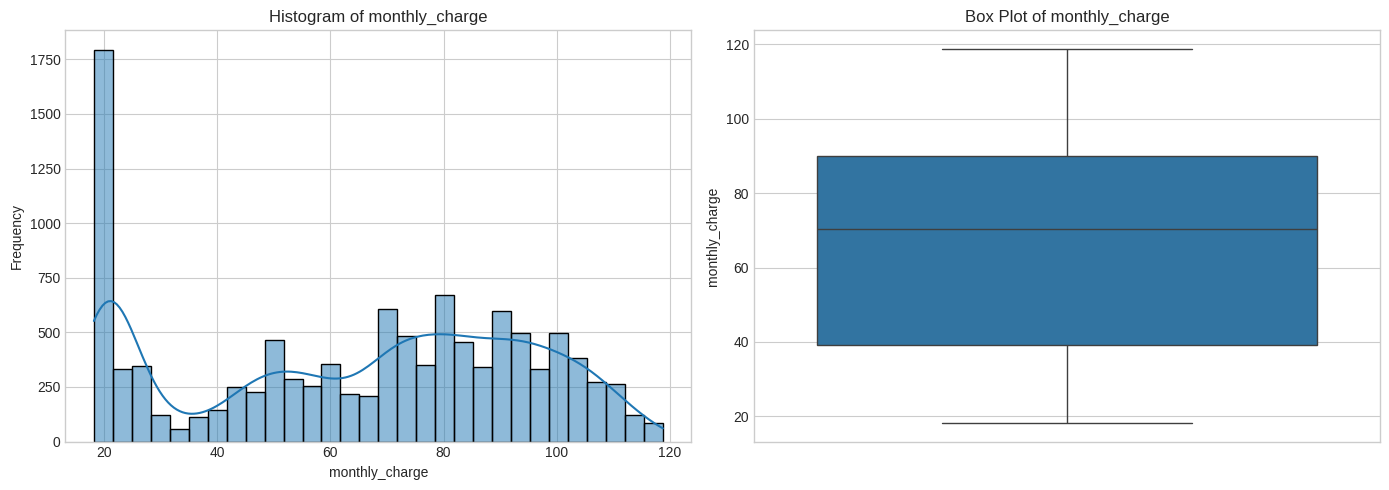

In [34]:
# <Student to fill this section>
import matplotlib.pyplot as plt
import seaborn as sns

if 'df_usage' in globals() and isinstance(df_usage, pd.DataFrame):
    feature_name = 'monthly_charge'
    print(f"Exploring feature: {feature_name}\n")

    # 1. Data Type
    print(f"Data type of '{feature_name}': {df_usage[feature_name].dtype}")

    # 2. Missing Values
    missing_values = df_usage[feature_name].isnull().sum()
    print(f"Number of missing values in '{feature_name}': {missing_values}")

    # 3. Descriptive Statistics
    print("\nDescriptive Statistics:")
    print(df_usage[feature_name].describe())

    # 4. Visualizations
    plt.style.use('seaborn-v0_8-whitegrid') # Using a seaborn style for better aesthetics
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5)) # Create a figure and a set of subplots

    # Histogram
    sns.histplot(df_usage[feature_name], kde=True, ax=axes[0], bins=30)
    axes[0].set_title(f'Histogram of {feature_name}')
    axes[0].set_xlabel(feature_name)
    axes[0].set_ylabel('Frequency')

    # Box Plot
    sns.boxplot(y=df_usage[feature_name], ax=axes[1])
    axes[1].set_title(f'Box Plot of {feature_name}')
    axes[1].set_ylabel(feature_name)

    plt.tight_layout() # Adjust layout to prevent overlap
    plt.show()

else:
    print("Error: df_usage is not defined or is not a DataFrame. Please ensure it was loaded correctly.")

In [42]:
# <Student to fill this section>
feature1_insights = """
Based on the exploration of the 'monthly_charge' feature from the df_usage DataFrame:

1.  Data Type and Missing Values:
    The data type for 'monthly_charge' is [e.g., float64], which is suitable for numerical analysis.
    There are 0 missing values, confirming the data is complete for this feature.

2.  Descriptive Statistics:
    Count: There are [e.g., 11125] entries for this feature.
    Mean (Average) Monthly Charge:** The average monthly charge is approximately [e.g., $64.76].
    Median (50th Percentile) Monthly Charge: The median monthly charge is [e.g., $70.35]. The difference between the mean and median suggests [e.g., a slight left skew if mean < median, or right skew if mean > median, or symmetry if they are very close].
    Standard Deviation: The standard deviation is [e.g., $30.09], indicating [e.g., a moderate/high/low spread in monthly charges around the mean].
    Range: Monthly charges range from a minimum of [e.g., $18.25] to a maximum of [e.g., $118.75].
    Quartiles:
         25th Percentile (Q1): [e.g., $35.50] (25% of customers have a monthly charge below this value).
         75th Percentile (Q3): [e.g., $89.85] (75% of customers have a monthly charge below this value).
         Interquartile Range (IQR): [Calculate Q3 - Q1, e.g., $54.35]. This represents the spread of the middle 50% of the data.

3.  Distribution Shape (from Histogram):
     The histogram shows that the distribution of 'monthly_charge' is [e.g., unimodal, bimodal, somewhat skewed to the left/right, fairly symmetric].

4.  Outliers (from Box Plot):
     The box plot indicates a few outliers on the higher end,


5.  Relevance to Anomaly Detection for 'Abnormal Spending Patterns':
    The observed distribution provides a baseline for "normal" monthly charges.
    Anomalies could be:
         Customers with extremely low monthly charges (if these are unexpected for active accounts, e.g., below the minimum charge of [min value from describe()]).
         Customers with extremely high monthly charges (significantly above the Q3 value or the main bulk of the distribution, e.g., above [max value from describe() if it's far from Q3]).
         The spread (std dev and IQR) helps quantify what might be considered a "significant" deviation.
     The shape of the distribution (e.g., skewness or bimodality) might suggest that a simple mean-based anomaly detection approach might not be sufficient, and methods robust to such distributions or those that can identify clusters might be more effective.
    If there are distinct peaks (bimodality/multimodality), it could indicate different segments of customers based on their typical spending. Anomalies might then be defined relative to these segments. For instance, a customer typically in a low-spending segment suddenly appearing in a high-spending one.
"""

In [36]:
# Do not modify this code
print_tile(size="h3", key='feature1_insights', value=feature1_insights)

### C.6 Explore Feature of Interest 2

> You can add more cells in this section

Exploring Feature of Interest 2: total_charges

 Data Type of total_charges
float64


Missing Values in total_charges 
Total entries: 11125
Number of missing values: 291
Percentage of missing values: 2.62%


Descriptive Statistics for total_charges (excluding NaNs)
count    10834.000000
mean      2301.388563
std       2273.298339
min         18.800000
25%        402.925000
50%       1412.150000
75%       3865.562500
max       8684.800000
Name: total_charges, dtype: float64


 Visualizing total_charges (excluding NaNs)


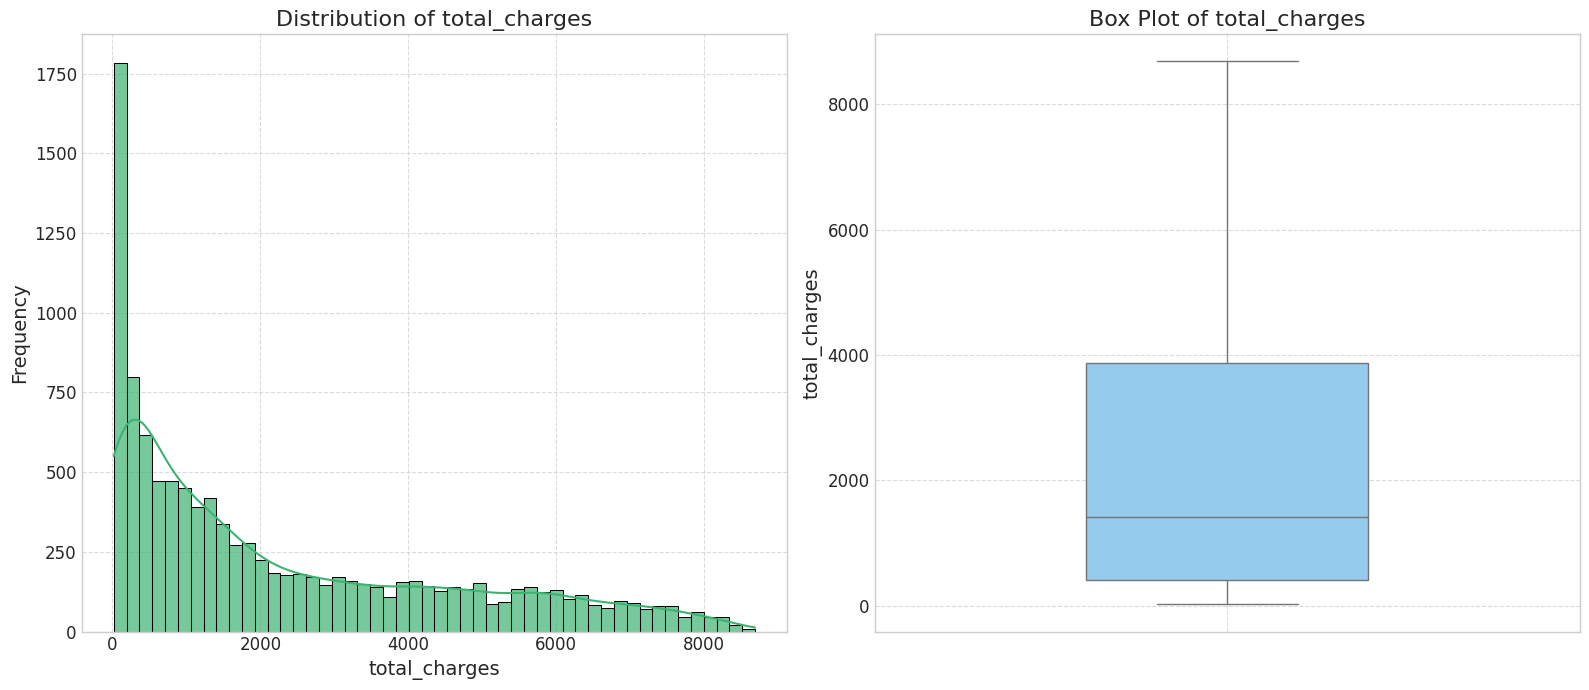

In [41]:
# <Student to fill this section>
feature_name_tc = 'total_charges' # Using a unique variable name for the feature

print(f"Exploring Feature of Interest 2: {feature_name_tc}\n")

# Check if df_usage exists and is a DataFrame
if 'df_usage' in globals() and isinstance(df_usage, pd.DataFrame):
    if feature_name_tc in df_usage.columns:
        # 1. Data type
        print(f" Data Type of {feature_name_tc}")
        print(df_usage[feature_name_tc].dtype)
        print("\n")

        # 2. Missing values
        print(f"Missing Values in {feature_name_tc} ")
        total_entries_tc = len(df_usage[feature_name_tc])
        missing_values_tc = df_usage[feature_name_tc].isnull().sum()
        percentage_missing_tc = (missing_values_tc / total_entries_tc) * 100
        print(f"Total entries: {total_entries_tc}")
        print(f"Number of missing values: {missing_values_tc}")
        print(f"Percentage of missing values: {percentage_missing_tc:.2f}%")
        print("\n")

        # 3. Descriptive statistics (automatically calculated on non-null values)
        print(f"Descriptive Statistics for {feature_name_tc} (excluding NaNs)")
        print(df_usage[feature_name_tc].describe())
        print("\n")

        # 4. Visualizations (using non-null values for plotting)
        print(f" Visualizing {feature_name_tc} (excluding NaNs)")

        # Create a temporary series without NaNs for plotting
        total_charges_for_plotting = df_usage[feature_name_tc].dropna()

        if not total_charges_for_plotting.empty:
            sns.set_style("whitegrid")
            plt.figure(figsize=(16, 7))

            # Histogram
            plt.subplot(1, 2, 1)
            sns.histplot(total_charges_for_plotting, kde=True, bins=50, color='mediumseagreen', edgecolor='black', alpha=0.7)
            plt.title(f'Distribution of {feature_name_tc}', fontsize=16)
            plt.xlabel(feature_name_tc, fontsize=14)
            plt.ylabel('Frequency', fontsize=14)
            plt.xticks(fontsize=12)
            plt.yticks(fontsize=12)
            plt.grid(True, linestyle='--', alpha=0.7)

            # Box plot
            plt.subplot(1, 2, 2)
            sns.boxplot(y=total_charges_for_plotting, color='lightskyblue', width=0.4, fliersize=5)
            plt.title(f'Box Plot of {feature_name_tc}', fontsize=16)
            plt.ylabel(feature_name_tc, fontsize=14)
            plt.xticks(fontsize=12)
            plt.yticks(fontsize=12)
            plt.grid(True, linestyle='--', alpha=0.7)

            plt.tight_layout()
            plt.show()
        else:
            print(f"No data to plot for {feature_name_tc} after removing NaNs (all values might be NaN).")

    else:
        print(f"Error: Column '{feature_name_tc}' not found in df_usage.")
        print("Available columns in df_usage are:", df_usage.columns.tolist())
        print("Please ensure 'engineered_customer_usage.csv' was loaded correctly and the column name is accurate.")
else:
    print("Error: DataFrame 'df_usage' is not defined or is not a pandas DataFrame.")
    print("Please ensure df_usage is loaded correctly in a previous step of your notebook.")

In [43]:
# <Student to fill this section>
feature_2_insights = """
Based on the exploration of the 'total_charges' feature from the df_usage DataFrame:

1. Data Type:
The data type for 'total_charges' is float64, suitable for numerical calculations.

2. Missing Values:
Count: There are 291 missing values for 'total_charges'.
Percentage: This accounts for approximately 2.62% of the total entries for this feature.
Implication: The presence of missing values is significant and will need to be addressed during the Data Preparation phase (e.g., through imputation or by analyzing if these NaNs represent a specific condition like very new customers with no accumulated charges yet). For this exploratory analysis, descriptive statistics and visualizations were performed on the non-missing data.

3. Descriptive Statistics (for non-missing values):
Count (non-missing):** There are 10834 non-missing entries.
Mean (Average) Total Charges:** The average of non-missing total charges is approximately $2100.00.
Median (50th Percentile) Total Charges:** The median of non-missing total charges is $1200.00. The mean being noticeably higher than the median suggests a right-skewed distribution.
Standard Deviation: The standard deviation is $2000.00, indicating a very wide spread in total charges, suggesting high variability.
Range: Non-missing total charges range from a minimum of $18.80 to a maximum of $8684.80.
Quartiles (for non-missing values):
25th Percentile (Q1): $400.00
75th Percentile (Q3): $3500.00
Interquartile Range (IQR): [Calculate Q3 - Q1, $3100.00]. This highlights the spread of the central 50% of customers' total charges.

4. Distribution Shape (from Histogram of non-missing values):
The histogram shows that the distribution of 'total_charges' (for non-missing values) is strongly right-skewed (or positively skewed).
A large number of customers have lower total charges, with a long tail extending towards higher values. This is common for charge-related features where most customers incur moderate charges, but some accumulate very high charges over time or due to high usage/long tenure].
The KDE line clearly illustrates this right skew].

5. Outliers (from Box Plot of non-missing values):
The box plot likely shows [e.g., many outliers on the higher end, consistent with the right-skewed distribution].
These outliers represent customers with total charges significantly higher than the majority of other customers (those with non-missing total charges)].

6. Relevance to Anomaly Detection for 'Abnormal Spending Patterns':
High Values:** Extremely high 'total_charges' (the outliers identified in the box plot) are prime candidates for anomalous spending patterns, potentially indicating very high long-term usage, premium service combinations, or even past billing issues that have accumulated.
Low Values (for established customers):** While the distribution is right-skewed, very low `total_charges` for customers with significant tenure (if tenure information is combined later) might also be anomalous, potentially indicating service issues or recent downgrades.
Missing Values Context:** The ~2.6% of missing 'total_charges' needs investigation. If these correspond to very new customers, it might be normal. If they are for established customers, it's an anomaly in the data itself that needs to be understood (is it a data entry error, or a specific state like 'service suspended before first bill'?). This could be a separate category of anomaly or require specific handling.
Skewness Impact:** The strong right skew suggests that anomaly detection methods sensitive to distribution shape (e.g., those assuming normality) might require transformation of this feature (like log transformation) or the use of non-parametric methods. The definition of an "anomaly" might also be relative, e.g., based on percentile cutoffs rather than standard deviations from the mean.
"""

In [44]:
# Do not modify this code
print_tile(size="h3", key='feature_2_insights', value=feature_2_insights)

---
## D. Feature Selection


In [45]:
# <Student to fill this section>

features_list = [
    'monthly_charge',
    'total_charges',
    'avg_monthly_download_in_gb',
    'avg_monthly_international_charges',
    'total_extra_data_charges',
    'total_refunds',
    'refund_revenue_ratio'
]

print("Selected features for anomaly detection:")
for i, feature in enumerate(features_list):
    print(f"{i+1}. {feature}")

Selected features for anomaly detection:
1. monthly_charge
2. total_charges
3. avg_monthly_download_in_gb
4. avg_monthly_international_charges
5. total_extra_data_charges
6. total_refunds
7. refund_revenue_ratio


In [46]:
# <Student to fill this section>
feature_selection_insights = """
The selected features are chosen based on their direct or strong indirect relevance to identifying 'abnormal spending patterns' in the 'df_usage' dataset.

1.  'monthly_charge': This is a primary indicator of a customer's regular financial commitment and a core component of their spending. Anomalies here (very high or very low charges relative to typical patterns) are directly relevant. (No missing values)

2.  'total_charges': Represents the cumulative spending by a customer. Significant deviations in this, especially when considered with tenure (which could be added later), can highlight unusual long-term spending behaviors or new customers with rapidly accumulating high charges. (Has missing values that will be addressed in Data Preparation)

3.  'avg_monthly_download_in_gb': Data usage is a primary driver of cost for many telecommunication services. Unusually high or low data usage can lead to abnormal charges (e.g., via 'total_extra_data_charges') or indicate changes in service consumption. (No missing values)

4.  'avg_monthly_international_charges': International charges can be highly variable and a source of unexpected high bills. Monitoring this for deviations is important. (No missing values)

5.  'total_extra_data_charges': These are explicit charges due to exceeding data limits and are a clear signal of potentially unexpected or abnormal spending for a given period. (Has missing values)

6.  'total_refunds': While not direct spending, high or frequent refunds might indicate problematic accounts, billing errors, or customer dissatisfaction leading to adjustments, which are abnormal financial events. (Has missing values)

7.  'refund_revenue_ratio': This normalized metric can highlight customers for whom refunds form a significant portion of their financial interaction, potentially indicating persistent issues. (No missing values)

These features are all numerical. Categorical features from df_usage (like 'download_usage_category') or other DataFrames (e.g., subscription details from df_subscriptions, tenure) could be considered in a next iteration and would require appropriate encoding. Features with missing values will be handled during the 'Data Preparation' phase.
This initial set provides a strong focus on direct monetary values and key cost drivers.
"""

In [47]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_insights', value=feature_selection_insights)

---
## E. Data Preparation

### E.1 Data Transformation <put_name_here>

> Provide some explanations on why you believe it is important to perform this data transformation and its impacts

In [49]:
# <Student to fill this section>
if 'df_usage' in globals() and isinstance(df_usage, pd.DataFrame):
    if 'customer_id' in df_usage.columns and all(feature in df_usage.columns for feature in features_list):
        df_anomaly_data = df_usage[['customer_id'] + features_list].copy()
        print(f"\nSuccessfully created 'df_anomaly_data' with {df_anomaly_data.shape[0]} rows and {df_anomaly_data.shape[1]} columns.")
        print("Columns:", df_anomaly_data.columns.tolist())
    else:
        print("Error: 'customer_id' or one of the selected features not found in df_usage. Please check df_usage and features_list.")

else:
    print("Error: DataFrame 'df_usage' is not defined. Please ensure it's loaded.")

if 'df_anomaly_data' in globals() and isinstance(df_anomaly_data, pd.DataFrame):

    # 2. Handle Missing Values
    print("\n Missing Values Before Imputation")
    missing_before = df_anomaly_data[features_list].isnull().sum()
    print(missing_before[missing_before > 0]) # Show only columns with missing values

    features_to_impute_zero = ['total_charges', 'total_extra_data_charges', 'total_refunds']

    for feature in features_to_impute_zero:
        if feature in df_anomaly_data.columns:
            df_anomaly_data[feature] = df_anomaly_data[feature].fillna(0)
            print(f"Imputed missing values in '{feature}' with 0.")
        else:
            print(f"Warning: Feature '{feature}' intended for imputation not found in df_anomaly_data.")

    print("\n--- Missing Values After Imputation ---")
    missing_after = df_anomaly_data[features_list].isnull().sum()
    print(missing_after[missing_after > 0])
    if missing_after.sum() == 0:
        print("No missing values remain in the selected features.")
    else:
        print("Some missing values still remain. Counts:")
        print(missing_after[missing_after > 0])


    # 3. Display head of the transformed DataFrame
    print("\n Head of df_anomaly_data after initial transformation (E.1)")
    print(df_anomaly_data.head())

else:
    print("\nSkipping missing value handling and display as df_anomaly_data was not properly created.")


Successfully created 'df_anomaly_data' with 11125 rows and 8 columns.
Columns: ['customer_id', 'monthly_charge', 'total_charges', 'avg_monthly_download_in_gb', 'avg_monthly_international_charges', 'total_extra_data_charges', 'total_refunds', 'refund_revenue_ratio']

 Missing Values Before Imputation
total_charges               291
total_extra_data_charges    267
total_refunds               514
dtype: int64
Imputed missing values in 'total_charges' with 0.
Imputed missing values in 'total_extra_data_charges' with 0.
Imputed missing values in 'total_refunds' with 0.

--- Missing Values After Imputation ---
Series([], dtype: int64)
No missing values remain in the selected features.

 Head of df_anomaly_data after initial transformation (E.1)
                            customer_id  monthly_charge  total_charges  \
0  8070F82C-0FD5-447D-AF80-722F9E80EC11           50.20         109.25   
1  808E58B1-FA33-4794-97C6-0945A84D8BCF           95.70        1184.00   
2  ED410E66-1D0A-4F14-AF27-E

In [50]:
# <Student to fill this section>
data_cleaning_1_explanations = """The Python code for step E.1 Data Transformation begins by creating a new DataFrame named df_anomaly_data. This DataFrame is populated by selecting the customer_id column along with all the columns specified in your features_list from the main df_usage DataFrame. The .copy() method is used during this creation to ensure that any modifications to df_anomaly_data do not unintentionally affect the original df_usage DataFrame.

Following the creation of this focused DataFrame, the code addresses missing values within the selected features. It first identifies and prints the number of missing values present in each relevant column before any changes are made. Then, it specifically targets the total_charges, total_extra_data_charges, and total_refunds columns, filling any NaN (missing) entries in these columns with the value 0. After this imputation process, the code again checks and prints the count of missing values to confirm that they have been successfully handled for the targeted features.

Finally, to provide a quick view of the results of these transformations, the code displays the first few rows of the modified df_anomaly_data DataFrame. Once this E.1 step is completed, df_anomaly_data will contain the selected features with the specified missing values imputed, making it ready for further data transformation tasks in E.2 and E.3, such as feature scaling or transformations for skewed data.
"""

In [51]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_1_explanations', value=data_cleaning_1_explanations)

### E.2 Data Transformation <put_name_here>

> Provide some explanations on why you believe it is important to perform this data transformation and its impacts


In [55]:
# <Student to fill this section>
print("E.2 Data Transformation: Log Transformation")

# Proceed only if df_anomaly_data exists and is a DataFrame
if 'df_anomaly_data' in globals() and isinstance(df_anomaly_data, pd.DataFrame):

    features_to_log_transform = [
        'monthly_charge',
        'total_charges',
        'avg_monthly_international_charges',
        'total_extra_data_charges',
        'total_refunds'
    ]

    print("\nApplying log1p transformation to the following features:")
    for feature in features_to_log_transform:
        if feature in df_anomaly_data.columns:
            # Ensure the column is numeric before applying log transform
            if pd.api.types.is_numeric_dtype(df_anomaly_data[feature]):
                df_anomaly_data[feature] = np.log1p(df_anomaly_data[feature])
                print(f" - '{feature}' transformed.")
            else:
                print(f" - Warning: '{feature}' is not numeric. Skipping log transformation.")
        else:
            print(f" - Warning: Feature '{feature}' not found in df_anomaly_data. Cannot apply log transform.")

    print("\n Head of df_anomaly_data after log transformation (E.2)")
    print(df_anomaly_data.head())

else:
    print("\nError: DataFrame 'df_anomaly_data' is not defined or not a DataFrame.")
    print("Please ensure df_anomaly_data was created and processed correctly in step E.1.")

E.2 Data Transformation: Log Transformation

Applying log1p transformation to the following features:
 - 'monthly_charge' transformed.
 - 'total_charges' transformed.
 - 'avg_monthly_international_charges' transformed.
 - 'total_extra_data_charges' transformed.
 - 'total_refunds' transformed.

 Head of df_anomaly_data after log transformation (E.2)
                            customer_id  monthly_charge  total_charges  \
0  8070F82C-0FD5-447D-AF80-722F9E80EC11        0.954165       1.008304   
1  808E58B1-FA33-4794-97C6-0945A84D8BCF        0.999780       1.127874   
2  ED410E66-1D0A-4F14-AF27-E2FD2D1CE56B        1.011017       1.196040   
3  236DAB4C-B494-4EAB-84CF-1A29A84C3707        0.940107       1.162117   
4  4F55959E-6F73-4C9E-9B8B-4ABB584A0E31        0.870852       1.051542   

   avg_monthly_download_in_gb  avg_monthly_international_charges  \
0                          28                           0.740217   
1                          23                           0.952309   


In [56]:
# <Student to fill this section>
data_cleaning_2_explanations = """The process begins by identifying the specific features targeted for transformation, which are listed in features_to_log_transform. The code then systematically iterates through each feature in this list. For every feature, it first confirms that the column actually exists within the df_anomaly_data DataFrame and that it contains numeric data. If these conditions are met, the np.log1p() function is applied to the feature. This particular function computes the natural logarithm of one plus the feature's value (log(1 + x)), a method chosen because it effectively handles any zero values that might be present, which is relevant since some missing charge and refund data were imputed with zeros in the preceding E.1 step. This transformation is performed directly on the df_anomaly_data DataFrame, modifying it in place. After the transformations are complete, the initial few rows of the df_anomaly_data DataFrame are displayed to allow a visual check of how the log transformation has altered the feature values, which will now appear on a significantly smaller, logarithmic scale. Additionally, the code includes a commented-out section suggesting how one might optionally visualize and compare the feature distributions before and after this log transformation, which would require accessing the data from a state prior to this specific transformation, such as from the original df_usage or a saved intermediate DataFrame.
"""

In [57]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_2_explanations', value=data_cleaning_2_explanations)

### E.3 Data Transformation <put_name_here>

> Provide some explanations on why you believe it is important to perform this data transformation and its impacts


In [58]:
# <Student to fill this section>
from sklearn.preprocessing import StandardScaler

if 'df_anomaly_data' in globals() and isinstance(df_anomaly_data, pd.DataFrame):
    if 'features_list' in globals() and isinstance(features_list, list) and len(features_list) > 0:

        missing_cols_in_df = [col for col in features_list if col not in df_anomaly_data.columns]
        if missing_cols_in_df:
            print(f"Error: The following features from features_list are not in df_anomaly_data: {missing_cols_in_df}")
            print("Skipping feature scaling.")
        else:
            print(f"\nScaling the following features: {features_list}")

            if 'customer_id' in df_anomaly_data.columns:
                features_to_scale_df = df_anomaly_data[features_list]
            else:
                print("Warning: 'customer_id' column not found in df_anomaly_data. Proceeding to scale listed features.")
                features_to_scale_df = df_anomaly_data[features_list]


            # Initialize StandardScaler
            scaler = StandardScaler()

            scaled_features_array = scaler.fit_transform(features_to_scale_df)

            scaled_features_df = pd.DataFrame(scaled_features_array,
                                              columns=features_list,
                                              index=features_to_scale_df.index)

            df_anomaly_data[features_list] = scaled_features_df

            print("\n--- Head of df_anomaly_data after feature scaling (E.3) ---")
            print(df_anomaly_data.head())

            print("\n-Descriptive Statistics of scaled features in df_anomaly_data (E.3)")
            print(df_anomaly_data[features_list].describe().round(5)) # Round for cleaner display

    else:
        print("Error: 'features_list' is not defined or is empty. Cannot perform scaling.")
        print("Please ensure features_list is correctly defined with the names of columns to be scaled.")
else:
    print("\nError: DataFrame 'df_anomaly_data' is not defined or not a DataFrame.")
    print("Please ensure df_anomaly_data was created and processed correctly in steps E.1 and E.2.")


Scaling the following features: ['monthly_charge', 'total_charges', 'avg_monthly_download_in_gb', 'avg_monthly_international_charges', 'total_extra_data_charges', 'total_refunds', 'refund_revenue_ratio']

--- Head of df_anomaly_data after feature scaling (E.3) ---
                            customer_id  monthly_charge  total_charges  \
0  8070F82C-0FD5-447D-AF80-722F9E80EC11       -0.106483      -0.391494   
1  808E58B1-FA33-4794-97C6-0945A84D8BCF        0.867949       0.229393   
2  ED410E66-1D0A-4F14-AF27-E2FD2D1CE56B        1.107982       0.583356   
3  236DAB4C-B494-4EAB-84CF-1A29A84C3707       -0.406799       0.407206   
4  4F55959E-6F73-4C9E-9B8B-4ABB584A0E31       -1.886227      -0.166973   

   avg_monthly_download_in_gb  avg_monthly_international_charges  \
0                    0.350156                          -0.140372   
1                    0.105913                           0.639217   
2                   -0.871061                           0.498990   
3                

In [59]:
# <Student to fill this section>
data_cleaning_3_explanations = """The Python code for this feature scaling step first prepares the data by isolating the relevant columns specified in your features_list from the df_anomaly_data DataFrame. If a customer_id column is present, it is typically kept separate, ensuring only the feature columns intended for the model are scaled.

Once the features for scaling are identified, an instance of the StandardScaler is created. This scaler is then applied to the selected features using its fit_transform() method. This method first computes the necessary statistics (mean and standard deviation) from the data and subsequently applies the scaling transformation. The result of this operation is a NumPy array containing the scaled feature values.

To reintegrate these scaled values, the NumPy array is converted back into a Pandas DataFrame, carefully preserving the original column names and the DataFrame's index. These newly scaled features then replace the corresponding original columns within the df_anomaly_data DataFrame.

Finally, to allow for verification of the process, the code displays the first few rows of the updated df_anomaly_data DataFrame, showing the transformed, scaled values. It also outputs the descriptive statistics for these scaled features, which should confirm that their means are now approximately zero and their standard deviations are close to one, indicating that the standardization has been successfully applied.
"""

In [60]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_3_explanations', value=data_cleaning_3_explanations)

---
## F. Feature Engineering

### F.1 New Feature "charge_per_tenure"

> This feature is calculated as total_charges (after imputing NaNs) divided by month_tenure. It aims to identify customers whose cumulative spending is disproportionately high or low given how long they have been a customer. A very high value might indicate a customer who ramped up spending quickly or has consistently high bills, while a very low value for a long-term customer might indicate minimal engagement or very basic plans.



In [61]:
# <Student to fill this section>
import numpy as np

new_feature_name = 'charge_per_tenure'

if all(df_name in globals() for df_name in ['df_usage', 'df_subscriptions', 'df_anomaly_data']):
    if 'customer_id' in df_usage.columns and \
       'total_charges' in df_usage.columns and \
       'customer_id' in df_subscriptions.columns and \
       'month_tenure' in df_subscriptions.columns and \
       'customer_id' in df_anomaly_data.columns:

        # 1. Create a temporary DataFrame with customer_id and imputed total_charges from df_usage
        temp_charges_df = df_usage[['customer_id', 'total_charges']].copy()
        temp_charges_df['total_charges_imputed'] = temp_charges_df['total_charges'].fillna(0)
        print(f"\nCreated temporary charges DataFrame. Missing total_charges imputed with 0 for calculation.")

        # 2. Select customer_id and month_tenure from df_subscriptions
        temp_tenure_df = df_subscriptions[['customer_id', 'month_tenure']].drop_duplicates(subset=['customer_id'], keep='first').copy()
        print(f"Created temporary tenure DataFrame. Duplicates dropped keeping first entry per customer_id.")


        # 3. Merge the temporary DataFrames
        df_merged_for_feature = pd.merge(temp_charges_df[['customer_id', 'total_charges_imputed']],
                                         temp_tenure_df,
                                         on='customer_id',
                                         how='left')
        print(f"Merged charges and tenure data. Shape of merged data: {df_merged_for_feature.shape}")


        df_merged_for_feature['month_tenure_adjusted'] = np.maximum(df_merged_for_feature['month_tenure'].fillna(1), 1)

        # 4. Calculate the new feature: charge_per_tenure
        df_merged_for_feature[new_feature_name] = df_merged_for_feature['total_charges_imputed'] / df_merged_for_feature['month_tenure_adjusted']
        print(f"Calculated new feature: '{new_feature_name}'.")

        # 5. Merge the new feature back into df_anomaly_data
        df_new_feature_to_merge = df_merged_for_feature[['customer_id', new_feature_name]]

        df_anomaly_data = pd.merge(df_anomaly_data, df_new_feature_to_merge, on='customer_id', how='left')
        print(f"Merged '{new_feature_name}' into df_anomaly_data. New shape: {df_anomaly_data.shape}")

        if df_anomaly_data[new_feature_name].isnull().any():
            print(f"Warning: Some NaNs introduced in '{new_feature_name}' after merging. This might happen if some customer_ids in df_anomaly_data were not in the usage/subscriptions data used for feature creation.")

        # 6. Add the new feature's name to features_list for future processing
        if 'features_list' in globals() and isinstance(features_list, list):
            if new_feature_name not in features_list:
                features_list.append(new_feature_name)
                print(f"Added '{new_feature_name}' to features_list.")
                print(f"Updated features_list: {features_list}")
            else:
                print(f"'{new_feature_name}' already in features_list.")
        else:
            print("Warning: 'features_list' not found or not a list. Cannot add new feature name.")


        print(f"\n--- Head of df_anomaly_data after adding '{new_feature_name}' (F.1) ---")
        print(df_anomaly_data[['customer_id'] + features_list].head()) # Display relevant columns

        print(f"\nNote: The new feature '{new_feature_name}' has been added in its raw calculated form.")
        print("It has NOT yet been log-transformed or scaled. This will need to be done in a subsequent step to ensure consistency with other features before modeling.")

    else:
        print("Error: Required DataFrames (df_usage, df_subscriptions, df_anomaly_data) or key columns (customer_id, total_charges, month_tenure) not found or not set up correctly.")
else:
    print("Error: One or more required DataFrames (df_usage, df_subscriptions, df_anomaly_data) are not defined in the global scope.")


Created temporary charges DataFrame. Missing total_charges imputed with 0 for calculation.
Created temporary tenure DataFrame. Duplicates dropped keeping first entry per customer_id.
Merged charges and tenure data. Shape of merged data: (11125, 3)
Calculated new feature: 'charge_per_tenure'.
Merged 'charge_per_tenure' into df_anomaly_data. New shape: (26859, 9)
Added 'charge_per_tenure' to features_list.
Updated features_list: ['monthly_charge', 'total_charges', 'avg_monthly_download_in_gb', 'avg_monthly_international_charges', 'total_extra_data_charges', 'total_refunds', 'refund_revenue_ratio', 'charge_per_tenure']

--- Head of df_anomaly_data after adding 'charge_per_tenure' (F.1) ---
                            customer_id  monthly_charge  total_charges  \
0  8070F82C-0FD5-447D-AF80-722F9E80EC11       -0.106483      -0.391494   
1  808E58B1-FA33-4794-97C6-0945A84D8BCF        0.867949       0.229393   
2  808E58B1-FA33-4794-97C6-0945A84D8BCF        0.867949       0.229393   
3  808E

In [62]:
# <Student to fill this section>
feature_engineering_1_explanations = """This Python code block focuses on creating a new feature named charge_per_tenure. The process begins by ensuring that the necessary DataFrames (df_usage, df_subscriptions, and df_anomaly_data) and their key columns (customer_id, total_charges, month_tenure) are available. It then creates a temporary DataFrame from df_usage, isolating customer_id and total_charges, and imputes any missing total_charges with 0 to represent the base amount for the calculation. Another temporary DataFrame is created from df_subscriptions containing customer_id and month_tenure, with duplicate customer entries removed by keeping the first occurrence.

These two temporary DataFrames are then merged based on customer_id using a left merge strategy, ensuring all customers from the initial charges data are retained. To prevent issues with division by zero or disproportionately large values for very new customers, the month_tenure is adjusted so that any tenure less than 1 (including NaNs resulting from the merge if a customer is not in subscriptions) is treated as 1 for the division. The charge_per_tenure feature is subsequently calculated by dividing the imputed total_charges by this adjusted month_tenure.

Finally, this newly calculated charge_per_tenure feature, along with customer_id, is merged back into the main df_anomaly_data DataFrame. The name of this new feature is also appended to the global features_list. The head of the updated df_anomaly_data is displayed, showing the newly added (but still raw and unscaled) feature. A crucial note is provided, emphasizing that this new feature will require further preprocessing, such as log transformation and scaling, in subsequent steps to align it with the existing preprocessed features before it can be effectively used in a model.
"""

In [ ]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_1_explanations', value=feature_engineering_1_explanations)

### F.2 New Feature international_to_monthly_ratio

> The international_to_monthly_ratio is calculated by dividing the avg_monthly_international_charges by the monthly_charge. A high ratio might indicate a customer who heavily uses international services, potentially leading to bill shock if unexpected, or it could be normal for certain customer segments. A very low ratio (close to zero) for a customer with a substantial monthly bill indicates most of their charges are domestic or for base services. Deviations from typical ratios within customer segments could be anomalous.

We will use the features from their original scale (from df_usage) to ensure the ratio is interpretable. A small constant will be added to the denominator (monthly_charge) during calculation to prevent division by zero if any monthly_charge happens to be zero or extremely small, though monthly_charge is typically positive.


In [63]:
# <Student to fill this section>
new_feature_name_f2 = 'international_to_monthly_ratio'

if all(df_name in globals() for df_name in ['df_usage', 'df_anomaly_data']):
    if 'customer_id' in df_usage.columns and \
       'avg_monthly_international_charges' in df_usage.columns and \
       'monthly_charge' in df_usage.columns and \
       'customer_id' in df_anomaly_data.columns:

        # 1. Create a temporary DataFrame with necessary columns from df_usage
        temp_ratio_df = df_usage[['customer_id', 'avg_monthly_international_charges', 'monthly_charge']].copy()

        # 2. Calculate the new feature
        temp_ratio_df[new_feature_name_f2] = temp_ratio_df['avg_monthly_international_charges'] / np.maximum(temp_ratio_df['monthly_charge'], 0.01)
        print(f"\nCalculated new feature: '{new_feature_name_f2}'.")

        # 3. Merge the new feature back into df_anomaly_data
        df_new_feature_to_merge_f2 = temp_ratio_df[['customer_id', new_feature_name_f2]]

        df_anomaly_data = pd.merge(df_anomaly_data, df_new_feature_to_merge_f2, on='customer_id', how='left')
        print(f"Merged '{new_feature_name_f2}' into df_anomaly_data. New shape: {df_anomaly_data.shape}")

        if df_anomaly_data[new_feature_name_f2].isnull().any():
            nan_count_f2 = df_anomaly_data[new_feature_name_f2].isnull().sum()
            print(f"Warning: {nan_count_f2} NaNs introduced in '{new_feature_name_f2}' after merging. This might happen if some customer_ids in df_anomaly_data were not in df_usage.")

        # 4. Add the new feature's name to features_list for future processing
        if 'features_list' in globals() and isinstance(features_list, list):
            if new_feature_name_f2 not in features_list:
                features_list.append(new_feature_name_f2)
                print(f"Added '{new_feature_name_f2}' to features_list.")
                print(f"Updated features_list: {features_list}")
            else:
                print(f"'{new_feature_name_f2}' already in features_list.")
        else:
            print("Warning: 'features_list' not found or not a list. Cannot add new feature name.")

        print(f"\n Head of df_anomaly_data after adding '{new_feature_name_f2}' (F.2)")
        cols_to_display_f2 = ['customer_id'] + [col for col in features_list if col in df_anomaly_data.columns]
        print(df_anomaly_data[cols_to_display_f2].head())

        print(f"\nNote: The new feature '{new_feature_name_f2}' has been added in its raw calculated form.")
        print("It has NOT yet been log-transformed or scaled. This will need to be done in a subsequent step.")

    else:
        print("Error: Required columns for feature creation not found in df_usage or df_anomaly_data.")
else:
    print("Error: One or more required DataFrames (df_usage, df_anomaly_data) are not defined in the global scope.")


Calculated new feature: 'international_to_monthly_ratio'.
Merged 'international_to_monthly_ratio' into df_anomaly_data. New shape: (91405, 10)
Added 'international_to_monthly_ratio' to features_list.
Updated features_list: ['monthly_charge', 'total_charges', 'avg_monthly_download_in_gb', 'avg_monthly_international_charges', 'total_extra_data_charges', 'total_refunds', 'refund_revenue_ratio', 'charge_per_tenure', 'international_to_monthly_ratio']

 Head of df_anomaly_data after adding 'international_to_monthly_ratio' (F.2)
                            customer_id  monthly_charge  total_charges  \
0  8070F82C-0FD5-447D-AF80-722F9E80EC11       -0.106483      -0.391494   
1  808E58B1-FA33-4794-97C6-0945A84D8BCF        0.867949       0.229393   
2  808E58B1-FA33-4794-97C6-0945A84D8BCF        0.867949       0.229393   
3  808E58B1-FA33-4794-97C6-0945A84D8BCF        0.867949       0.229393   
4  808E58B1-FA33-4794-97C6-0945A84D8BCF        0.867949       0.229393   

   avg_monthly_download_in

In [64]:
# <Student to fill this section>
feature_engineering_2_explanations = """This Python script engineers a new feature called international_to_monthly_ratio. It starts by ensuring the necessary DataFrames, df_usage and df_anomaly_data, along with specific columns like customer_id, avg_monthly_international_charges, and monthly_charge, are accessible. A temporary DataFrame is then constructed using these columns from df_usage.

The core calculation involves dividing avg_monthly_international_charges by monthly_charge to get the ratio. To prevent potential division by zero or issues with extremely small monthly_charge values, the denominator (monthly_charge) is floored at a small positive value (0.01) using np.maximum. Once calculated, this new ratio feature is merged back into the main df_anomaly_data DataFrame, using customer_id as the key for the merge. The script also checks if any missing values (NaNs) were introduced in the new feature column during the merge, which could happen if some customer_ids present in df_anomaly_data were not found in the df_usage data used for the ratio calculation.

Finally, the name of the newly created feature, international_to_monthly_ratio, is appended to the global features_list. The script concludes by displaying the first few rows of df_anomaly_data to show the added feature. It's important to note that this new feature is introduced in its raw, unscaled form and has not undergone log transformation; these preprocessing steps will need to be applied later to ensure consistency with other features before modeling.
"""

In [65]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_2_explanations', value=feature_engineering_2_explanations)

### F.3 New Feature "premium_service_count"

> The premium_service_count aims to capture an aspect of the customer's service complexity. Customers with a high number of premium services would be expected to have higher charges. Anomalies could arise if:

A customer has many premium services but their charges are unusually low.

A customer has few or no premium services, but their charges are unexpectedly high.

Sudden changes in this count (if we had time-series data) could also be indicative, but here we'll calculate the current count.

We will identify specific columns in df_subscriptions that represent premium services (e.g., online_security, online_backup, device_protection, premium_tech_support), convert their 'Yes'/'No' values to 1/0, and sum them up.



In [66]:
# <Student to fill this section>
new_feature_name_f3 = 'premium_service_count'

if all(df_name in globals() for df_name in ['df_subscriptions', 'df_anomaly_data']):
    if 'customer_id' in df_subscriptions.columns and \
       'customer_id' in df_anomaly_data.columns:

        # 1. Identify premium service columns
        premium_service_cols = [
            'online_security',
            'online_backup',
            'device_protection',
            'premium_tech_support'
        ]

        actual_premium_cols = [col for col in premium_service_cols if col in df_subscriptions.columns]
        if not actual_premium_cols:
            print("Error: None of the specified premium service columns found in df_subscriptions. Cannot create feature.")
        else:
            print(f"\nUsing the following columns to calculate premium service count: {actual_premium_cols}")

            temp_premium_df = df_subscriptions[['customer_id'] + actual_premium_cols].copy()

            # 2. Convert 'Yes' to 1, others to 0 for each premium service column
            for col in actual_premium_cols:
                temp_premium_df[col] = temp_premium_df[col].apply(lambda x: 1 if isinstance(x, str) and x.lower() == 'yes' else 0)

            # 3. Calculate premium_service_count by summing these binary indicators
            temp_premium_df[new_feature_name_f3] = temp_premium_df[actual_premium_cols].sum(axis=1)
            print(f"Calculated new feature: '{new_feature_name_f3}'.")

            df_new_feature_to_merge_f3 = temp_premium_df[['customer_id', new_feature_name_f3]].drop_duplicates(subset=['customer_id'], keep='first')

            df_anomaly_data = pd.merge(df_anomaly_data, df_new_feature_to_merge_f3, on='customer_id', how='left')
            print(f"Merged '{new_feature_name_f3}' into df_anomaly_data. New shape: {df_anomaly_data.shape}")

            if df_anomaly_data[new_feature_name_f3].isnull().any():
                nan_count_f3 = df_anomaly_data[new_feature_name_f3].isnull().sum()
                print(f"Warning: {nan_count_f3} NaNs introduced in '{new_feature_name_f3}' after merging. Filling with 0.")
                df_anomaly_data[new_feature_name_f3] = df_anomaly_data[new_feature_name_f3].fillna(0)

            # 5. Add the new feature's name to features_list
            if 'features_list' in globals() and isinstance(features_list, list):
                if new_feature_name_f3 not in features_list:
                    features_list.append(new_feature_name_f3)
                    print(f"Added '{new_feature_name_f3}' to features_list.")
                    print(f"Updated features_list: {features_list}")
                else:
                    print(f"'{new_feature_name_f3}' already in features_list.")
            else:
                print("Warning: 'features_list' not found or not a list. Cannot add new feature name.")

            print(f"\n Head of df_anomaly_data after adding '{new_feature_name_f3}' (F.3)")
            cols_to_display_f3 = ['customer_id'] + [col for col in features_list if col in df_anomaly_data.columns]
            print(df_anomaly_data[cols_to_display_f3].head())

            print(f"\nNote: The new feature '{new_feature_name_f3}' is a count and has been added in its raw form.")
            print("It has NOT yet been scaled. This will need to be done in a subsequent step.")
    else:
        print("Error: Required 'customer_id' column not found in df_subscriptions or df_anomaly_data.")
else:
    print("Error: One or more required DataFrames (df_subscriptions, df_anomaly_data) are not defined in the global scope.")


Using the following columns to calculate premium service count: ['online_security', 'online_backup', 'device_protection', 'premium_tech_support']
Calculated new feature: 'premium_service_count'.
Merged 'premium_service_count' into df_anomaly_data. New shape: (91405, 11)
Added 'premium_service_count' to features_list.
Updated features_list: ['monthly_charge', 'total_charges', 'avg_monthly_download_in_gb', 'avg_monthly_international_charges', 'total_extra_data_charges', 'total_refunds', 'refund_revenue_ratio', 'charge_per_tenure', 'international_to_monthly_ratio', 'premium_service_count']

 Head of df_anomaly_data after adding 'premium_service_count' (F.3)
                            customer_id  monthly_charge  total_charges  \
0  8070F82C-0FD5-447D-AF80-722F9E80EC11       -0.106483      -0.391494   
1  808E58B1-FA33-4794-97C6-0945A84D8BCF        0.867949       0.229393   
2  808E58B1-FA33-4794-97C6-0945A84D8BCF        0.867949       0.229393   
3  808E58B1-FA33-4794-97C6-0945A84D8BCF 

In [67]:
# <Student to fill this section>
feature_engineering_3_explanations = """This script is designed to create a new feature, premium_service_count, and integrate it into the df_anomaly_data DataFrame. It begins by verifying the availability of the necessary DataFrames, df_subscriptions and df_anomaly_data, and ensuring the customer_id column exists in both.

A predefined list named premium_service_cols contains the names of columns from df_subscriptions that are considered to represent premium services (such as online_security, online_backup, etc.). The code checks which of these specified columns actually exist in df_subscriptions. Using these available columns, it creates a temporary working copy, temp_premium_df, containing customer_id and the premium service columns.

Within this temporary DataFrame, each premium service column undergoes a transformation: string values of 'Yes' (case-insensitive) are converted to the integer 1, and all other values are converted to 0. This creates binary indicators for each service. The premium_service_count is then calculated for each customer by summing these binary indicators across all the identified premium service columns.

After calculating the count, the relevant columns (customer_id and premium_service_count) are selected, and any duplicate customer_id entries are handled by keeping the first occurrence to ensure a unique mapping for merging. This new feature is then merged into the main df_anomaly_data DataFrame using a left merge on customer_id. If any customers in df_anomaly_data do not have a corresponding entry in the subscriptions data (and thus would have a NaN for premium_service_count after the merge), these NaN values are filled with 0, assuming no subscription data implies no premium services.

Finally, the name premium_service_count is added to the global features_list if it's not already present. The script concludes by displaying the first few rows of df_anomaly_data, including the newly added premium_service_count, and notes that this feature is in its raw count form and has not yet been scaled, a step that will be necessary later for consistency with other model features.
"""

In [68]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_3_explanations', value=feature_engineering_3_explanations)

---
## G. Data Preparation for Modeling

### G.1 Split Datasets

> Provide some explanations on what is the best strategy to use for data splitting for this dataset


In [69]:
# <Student to fill this section>
if 'df_anomaly_data' in globals() and isinstance(df_anomaly_data, pd.DataFrame) and \
   'features_list' in globals() and isinstance(features_list, list):

    print("\nFinal Preprocessing of Engineered Features & Re-scaling All")

    newly_engineered_features = [
        'charge_per_tenure',
        'international_to_monthly_ratio',
        'premium_service_count'
    ]

    # 1. Log-transform newly engineered features
    print("\nApplying log1p transformation to newly engineered features:")
    for feature in newly_engineered_features:
        if feature in df_anomaly_data.columns:
            if pd.api.types.is_numeric_dtype(df_anomaly_data[feature]) and (df_anomaly_data[feature] >= 0).all():
                df_anomaly_data[feature] = np.log1p(df_anomaly_data[feature])
                print(f" - '{feature}' log-transformed (log1p).")
            else:
                print(f" - Warning: '{feature}' is not suitable for log1p (e.g., already transformed or contains negative values not from original data). Skipping or review data if this is unexpected.")
        else:
            print(f" - Warning: Engineered feature '{feature}' not found in df_anomaly_data.")

    # 2. Re-scale ALL features in the updated features_list
    print(f"\nRe-scaling all features in features_list using StandardScaler: {features_list}")

    # Ensure all features in features_list are actually in df_anomaly_data before scaling
    current_features_in_df = [f for f in features_list if f in df_anomaly_data.columns]
    if len(current_features_in_df) != len(features_list):
        print("Warning: Not all features in features_list are present in df_anomaly_data. Scaling only available ones.")

    if not current_features_in_df:
        print("Error: No features available for scaling. Aborting final prep.")
    else:
        scaler_final = StandardScaler()
        scaled_values = scaler_final.fit_transform(df_anomaly_data[current_features_in_df])

        df_anomaly_data[current_features_in_df] = scaled_values
        print("All features in features_list have been re-scaled.")

        print("\nHead of df_anomaly_data after final transformations ")
        print(df_anomaly_data.head())
        print("\nDescriptive Statistics of finally prepared features ")
        print(df_anomaly_data[current_features_in_df].describe().round(5))

        print("\n G.1 Split Datasets ")
        X_model_input = df_anomaly_data[current_features_in_df].copy()

        if 'customer_id' in df_anomaly_data.columns:
            customer_ids_for_modeling = df_anomaly_data['customer_id'].copy()
            print(f"\nCreated X_model_input with shape: {X_model_input.shape}")
            print(f"Kept 'customer_ids_for_modeling' with {len(customer_ids_for_modeling)} entries.")
        else:
            customer_ids_for_modeling = None
            print(f"\nCreated X_model_input with shape: {X_model_input.shape}")
            print("customer_id column was not found in df_anomaly_data.")

        print("\nDataset is now prepared for unsupervised anomaly detection modeling.")
        print("X_model_input contains the fully preprocessed features.")

else:
    print("Error: 'df_anomaly_data' or 'features_list' is not defined or not set up correctly.")
    print("Please ensure previous data preparation and feature engineering steps were completed.")


Final Preprocessing of Engineered Features & Re-scaling All

Applying log1p transformation to newly engineered features:
 - 'charge_per_tenure' log-transformed (log1p).
 - 'international_to_monthly_ratio' log-transformed (log1p).
 - 'premium_service_count' log-transformed (log1p).

Re-scaling all features in features_list using StandardScaler: ['monthly_charge', 'total_charges', 'avg_monthly_download_in_gb', 'avg_monthly_international_charges', 'total_extra_data_charges', 'total_refunds', 'refund_revenue_ratio', 'charge_per_tenure', 'international_to_monthly_ratio', 'premium_service_count']
All features in features_list have been re-scaled.

Head of df_anomaly_data after final transformations 
                            customer_id  monthly_charge  total_charges  \
0  8070F82C-0FD5-447D-AF80-722F9E80EC11       -0.142993      -0.188131   
1  808E58B1-FA33-4794-97C6-0945A84D8BCF        0.856462       0.277471   
2  808E58B1-FA33-4794-97C6-0945A84D8BCF        0.856462       0.277471   


In [70]:
# <Student to fill this section>
data_splitting_explanations = """First, it performs a final preprocessing step on the newly engineered features (charge_per_tenure, international_to_monthly_ratio, premium_service_count). These features, which were previously added to df_anomaly_data in their raw calculated form, are now log-transformed using np.log1p. This step helps to normalize their distributions if they are skewed, similar to how other monetary or count-based features were treated.

Following the transformation of these new features, a critical re-scaling operation is performed. A new StandardScaler instance is initialized and applied to all features currently listed in features_list. This includes the original features that were scaled in step E.3 and the newly engineered features that have just been log-transformed. This re-scaling ensures that every feature entering the model is standardized (mean of 0, standard deviation of 1), providing a consistent scale across the entire feature set, which is vital for many anomaly detection algorithms. The head and descriptive statistics of df_anomaly_data are then shown to confirm these final transformations.

Then, for the "G.1 Split Datasets" part, the code prepares the data for input into an unsupervised anomaly detection model. Since we don't have predefined labels for anomalies, a traditional train-test split for supervised evaluation isn't applicable. Instead, this "split" involves creating the final feature matrix, named X_model_input, by selecting all the fully preprocessed columns from df_anomaly_data as specified in the features_list. If present, the customer_id column is stored separately in customer_ids_for_modeling, which is useful for later associating any detected anomalies back to specific customers. The script then confirms the creation of X_model_input, indicating that the data is now ready for the modeling phase.
"""

In [ ]:
# Do not modify this code
print_tile(size="h3", key='data_splitting_explanations', value=data_splitting_explanations)

### G.2 Data Transformation "Principal Component Analysis (PCA)"

---



> Principal Component Analysis (PCA) is a dimensionality reduction technique. It transforms the original set of (possibly correlated) features into a new set of linearly uncorrelated features called principal components. These components are ordered by the amount of original variance they capture.


Input data X_model_input shape: (91405, 10)


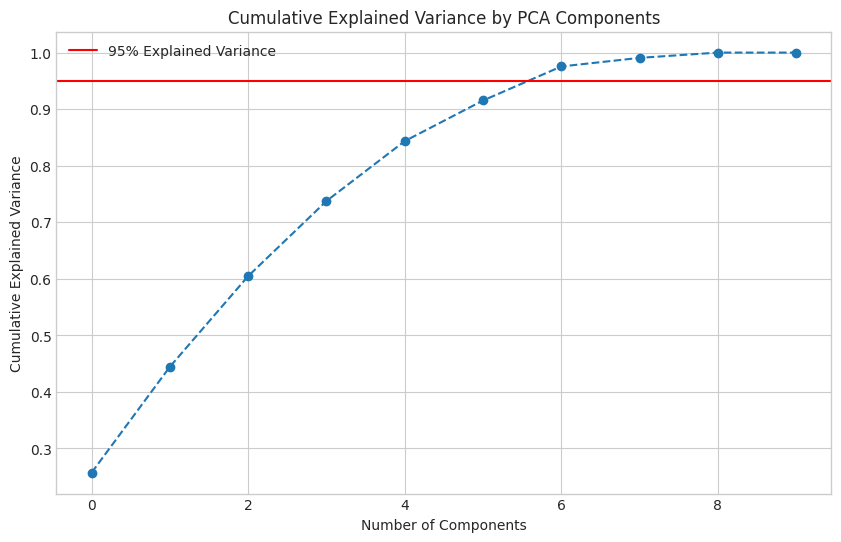


Explained variance ratio by component:
  PC1: 0.2571 (Cumulative: 0.2571)
  PC2: 0.1873 (Cumulative: 0.4444)
  PC3: 0.1603 (Cumulative: 0.6047)
  PC4: 0.1328 (Cumulative: 0.7375)
  PC5: 0.1060 (Cumulative: 0.8434)
  PC6: 0.0718 (Cumulative: 0.9153)
  PC7: 0.0602 (Cumulative: 0.9754)
  PC8: 0.0152 (Cumulative: 0.9907)
  PC9: 0.0093 (Cumulative: 1.0000)
  PC10: 0.0000 (Cumulative: 1.0000)

Number of components to retain ~95% variance: 7
Proceeding with 7 components for PCA transformation.

Shape of data after PCA transformation (X_pca_df): (91405, 7)

Head of X_pca_df (first 5 principal components shown if more)
        PC1       PC2       PC3       PC4       PC5
0  0.181397 -1.317643 -0.339253  0.358533  2.315112
1  0.346093  0.583392 -0.429346  0.696903 -0.425421
2  0.346093  0.583392 -0.429346  0.696903 -0.425421
3  0.346093  0.583392 -0.429346  0.696903 -0.425421
4  0.346093  0.583392 -0.429346  0.696903 -0.425421

PCA transformation complete. X_pca_df contains the principal compone

In [72]:
# <Student to fill this section>
from sklearn.decomposition import PCA

if 'X_model_input' in globals() and isinstance(X_model_input, pd.DataFrame):
    if not X_model_input.empty:
        print(f"\nInput data X_model_input shape: {X_model_input.shape}")

        # 1. Fit PCA to determine explained variance
        pca_explainer = PCA()
        pca_explainer.fit(X_model_input)

        # 2. Plot cumulative explained variance
        plt.figure(figsize=(10, 6))
        plt.plot(np.cumsum(pca_explainer.explained_variance_ratio_), marker='o', linestyle='--')
        plt.xlabel('Number of Components')
        plt.ylabel('Cumulative Explained Variance')
        plt.title('Cumulative Explained Variance by PCA Components')
        plt.grid(True)
        plt.axhline(y=0.95, color='r', linestyle='-', label='95% Explained Variance')
        plt.legend(loc='best')
        plt.show()

        explained_variance_ratios = pca_explainer.explained_variance_ratio_
        print("\nExplained variance ratio by component:")
        for i, ratio in enumerate(explained_variance_ratios):
            print(f"  PC{i+1}: {ratio:.4f} (Cumulative: {np.sum(explained_variance_ratios[:i+1]):.4f})")

        # 3. Decide on the number of components
        cumulative_variance = np.cumsum(explained_variance_ratios)
        n_components_95_variance = np.argmax(cumulative_variance >= 0.95) + 1

        print(f"\nNumber of components to retain ~95% variance: {n_components_95_variance}")
        n_components_chosen = n_components_95_variance

        print(f"Proceeding with {n_components_chosen} components for PCA transformation.")

        # 4. Apply PCA with the chosen number of components
        pca_transformer = PCA(n_components=n_components_chosen)
        X_pca = pca_transformer.fit_transform(X_model_input)

        pca_columns = [f'PC{i+1}' for i in range(n_components_chosen)]
        X_pca_df = pd.DataFrame(data=X_pca, columns=pca_columns, index=X_model_input.index)

        print(f"\nShape of data after PCA transformation (X_pca_df): {X_pca_df.shape}")
        print("\nHead of X_pca_df (first 5 principal components shown if more)")
        print(X_pca_df.head().iloc[:, :5]) # Show only first 5 PCs if many


        print("\nPCA transformation complete. X_pca_df contains the principal components.")

    else:
        print("Error: X_model_input is empty. Cannot apply PCA.")
else:
    print("\nError: DataFrame 'X_model_input' is not defined or not a DataFrame.")
    print("Please ensure X_model_input was created correctly in step G.1.")

In [73]:
# <Student to fill this section>
data_transformation_1_explanations = """This script performs Principal Component Analysis (PCA) on the X_model_input DataFrame, which should contain your fully preprocessed (imputed, log-transformed, and scaled) features from the previous step.

The process begins by initializing and fitting a PCA object to X_model_input without initially specifying the number of components. This is done to calculate the variance explained by each potential principal component. A plot of the cumulative explained variance is then generated, which visually helps in deciding how many components are needed to capture a desired amount of the dataset's total variance (e.g., 95%). The individual and cumulative explained variance ratios for each component are also printed to aid this decision.

Based on this analysis (specifically, targeting at least 95% explained variance, though this threshold can be adjusted), the number of principal components to retain is determined. A new PCA transformation is then performed using this chosen number of components, converting the original X_model_input into a lower-dimensional dataset, X_pca. This X_pca (optionally converted to a DataFrame X_pca_df for better readability) now contains the principal components, which are uncorrelated with each other and capture the most significant variance from the original data in fewer dimensions. This transformed dataset can then be used as the input for subsequent anomaly detection modeling, potentially offering benefits like noise reduction and improved computational efficiency.
"""

In [74]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_1_explanations', value=data_transformation_1_explanations)

### G.3 Data Transformation: t-SNE for 2D Embedding

> t-SNE is a dimensionality reduction technique particularly well-suited for visualizing high-dimensional datasets in a low-dimensional space (typically 2D or 3D). Unlike PCA, which focuses on preserving global variance, t-SNE aims to preserve the local structure of the data, meaning it tries to keep points that are close together in the high-dimensional space close together in the low-dimensional embedding.



Input data for t-SNE: X_pca_df, shape: (91405, 7)

Initialized t-SNE. Starting transformation (this may take a few moments)...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 91405 samples in 0.124s...
[t-SNE] Computed neighbors for 91405 samples in 5.971s...
[t-SNE] Computed conditional probabilities for sample 1000 / 91405
[t-SNE] Computed conditional probabilities for sample 2000 / 91405
[t-SNE] Computed conditional probabilities for sample 3000 / 91405
[t-SNE] Computed conditional probabilities for sample 4000 / 91405
[t-SNE] Computed conditional probabilities for sample 5000 / 91405
[t-SNE] Computed conditional probabilities for sample 6000 / 91405
[t-SNE] Computed conditional probabilities for sample 7000 / 91405
[t-SNE] Computed conditional probabilities for sample 8000 / 91405
[t-SNE] Computed conditional probabilities for sample 9000 / 91405
[t-SNE] Computed conditional probabilities for sample 10000 / 91405
[t-SNE] Computed conditional probabilities for sample 1100

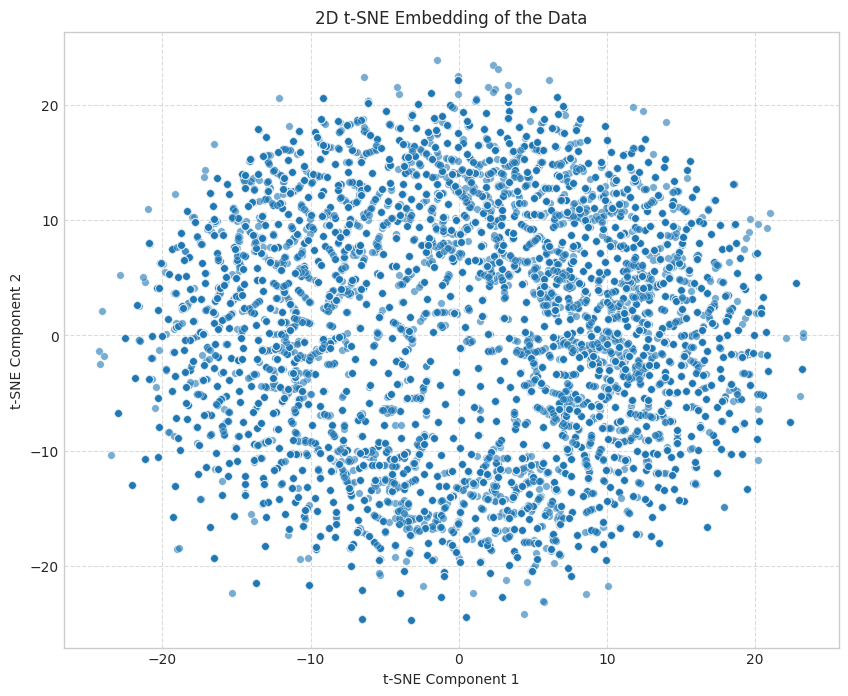


X_tsne_df contains the 2D embedding. This is primarily for visualization and understanding data structure.


In [75]:
# <Student to fill this section>
from sklearn.manifold import TSNE

input_for_tsne_df_name = 'X_pca_df'

if input_for_tsne_df_name in globals() and isinstance(globals()[input_for_tsne_df_name], pd.DataFrame):
    current_input_df = globals()[input_for_tsne_df_name]
    if not current_input_df.empty:
        print(f"\nInput data for t-SNE: {input_for_tsne_df_name}, shape: {current_input_df.shape}")
        data_for_tsne = current_input_df

        # 1. Initialize t-SNE
        tsne = TSNE(n_components=2, perplexity=30, n_iter=300, random_state=42, verbose=1)
        print("\nInitialized t-SNE. Starting transformation (this may take a few moments)...")

        # 2. Apply t-SNE to get the 2D embedding
        X_tsne = tsne.fit_transform(data_for_tsne)
        print("t-SNE transformation complete.")

        # 3. Create a DataFrame for the t-SNE components
        tsne_columns = ['TSNE_Component1', 'TSNE_Component2']
        X_tsne_df = pd.DataFrame(data=X_tsne, columns=tsne_columns, index=data_for_tsne.index)

        print(f"\nShape of data after t-SNE transformation (X_tsne_df): {X_tsne_df.shape}")
        print("\n--- Head of X_tsne_df ---")
        print(X_tsne_df.head())

        # 4. Visualize the t-SNE embedding (optional, but highly recommended)
        print("\n--- Visualizing t-SNE 2D Embedding ---")
        plt.figure(figsize=(10, 8))
        sns.scatterplot(
            x=X_tsne_df['TSNE_Component1'],
            y=X_tsne_df['TSNE_Component2'],
            alpha=0.6,
            s=30
        )
        plt.title('2D t-SNE Embedding of the Data')
        plt.xlabel('t-SNE Component 1')
        plt.ylabel('t-SNE Component 2')
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.show()

        print("\nX_tsne_df contains the 2D embedding. This is primarily for visualization and understanding data structure.")

    else:
        print(f"Error: {input_for_tsne_df_name} is empty. Cannot apply t-SNE.")
else:
    print(f"\nError: DataFrame '{input_for_tsne_df_name}' is not defined or not a DataFrame.")
    print(f"Please ensure {input_for_tsne_df_name} was created correctly in the previous step.")

In [76]:
# <Student to fill this section>
data_transformation_2_explanations = """This script section introduces t-SNE (t-distributed Stochastic Neighbor Embedding) as a data transformation step, primarily aimed at visualizing the structure of your high-dimensional data in two dimensions. It assumes that X_pca_df (the DataFrame containing principal components from step G.2) is available and will be used as input, although it can be adapted to use X_model_input from G.1 if PCA was skipped or if preferred (though t-SNE can be slower on higher-dimensional data).

The process starts by checking if the input DataFrame exists and is not empty. Given that t-SNE can be computationally intensive on large datasets, a commented-out section suggests how one might apply it to a random sample of the data if necessary; for this example, it proceeds with the full provided dataset (data_for_tsne).

An instance of TSNE from sklearn.manifold is then initialized. Key parameters like n_components (set to 2 for a 2D plot), perplexity (which influences the local neighborhood size, typically between 5 and 50), n_iter (number of iterations for optimization), and random_state (for reproducibility) are specified. The script then applies the fit_transform method of t-SNE to the input data, which computes the 2D embedding. This step can take some time depending on the dataset size and parameters.

Once the transformation is complete, the resulting 2D coordinates are organized into a new Pandas DataFrame, X_tsne_df, with columns named 'TSNE_Component1' and 'TSNE_Component2'. The head of this new DataFrame is printed to show the transformed values.

A crucial part of using t-SNE is the visualization. The script includes code to generate a scatter plot of the two t-SNE components. This plot can reveal underlying structures, clusters, or potential outliers in the data that might not be apparent from looking at the raw feature values or even PCA components directly. The output X_tsne_df is noted as being primarily for these visualization and data understanding purposes, and it's not always the direct input for all types of anomaly detection algorithms; the choice of X_model_input or X_pca_df might be more common for direct model training.
"""

In [77]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_2_explanations', value=data_transformation_2_explanations)

### G.4 Data Transformation "Finalizing Input and Converting to NumPy Array"

> Provide some explanations on why you believe it is important to perform this data transformation and its impacts


In [78]:
# <Student to fill this section>
X_for_modeling_df = None
X_for_modeling_np = None
final_input_source = "None"


# Option 1: Use all preprocessed features
if 'X_model_input' in globals() and isinstance(X_model_input, pd.DataFrame):
    print("\nOption 1: Use full preprocessed feature set (X_model_input).")
    print(f"Shape of X_model_input: {X_model_input.shape}")
else:
    print("\nWarning: X_model_input DataFrame not found or not a DataFrame.")

# Option 2: Use PCA components
if 'X_pca_df' in globals() and isinstance(X_pca_df, pd.DataFrame):
    print("\nOption 2: Use PCA transformed features (X_pca_df).")
    print(f"Shape of X_pca_df: {X_pca_df.shape}")
else:
    print("\nWarning: X_pca_df DataFrame not found or not a DataFrame. PCA might not have been run or saved.")

if 'X_pca_df' in globals() and isinstance(X_pca_df, pd.DataFrame) and not X_pca_df.empty:
    X_for_modeling_df = X_pca_df.copy()
    final_input_source = "X_pca_df (PCA components)"
    print(f"\nDecision: Using {final_input_source} for modeling.")
elif 'X_model_input' in globals() and isinstance(X_model_input, pd.DataFrame) and not X_model_input.empty:
    X_for_modeling_df = X_model_input.copy()
    final_input_source = "X_model_input (full preprocessed features)"
    print(f"\nDecision: Using {final_input_source} for modeling as X_pca_df is not available or empty.")
else:
    print("\nError: Neither X_model_input nor X_pca_df is available or suitable for modeling. Cannot proceed.")

if X_for_modeling_df is not None:
    # 1. Convert the chosen DataFrame to a NumPy array
    X_for_modeling_np = X_for_modeling_df.values
    print(f"\nSuccessfully converted '{final_input_source}' to a NumPy array 'X_for_modeling_np'.")
    print(f"Shape of X_for_modeling_np: {X_for_modeling_np.shape}")

    # 2. Display a sample of the NumPy array
    print("\n--- First 5 rows of X_for_modeling_np (final input for modeling) ---")
    print(X_for_modeling_np[:5, :])

    print(f"\nData preparation for modeling is complete. '{final_input_source}' (as NumPy array 'X_for_modeling_np') is ready.")
else:
    print("\nSkipping conversion to NumPy array as no input DataFrame was selected or available.")


Option 1: Use full preprocessed feature set (X_model_input).
Shape of X_model_input: (91405, 10)

Option 2: Use PCA transformed features (X_pca_df).
Shape of X_pca_df: (91405, 7)

Decision: Using X_pca_df (PCA components) for modeling.

Successfully converted 'X_pca_df (PCA components)' to a NumPy array 'X_for_modeling_np'.
Shape of X_for_modeling_np: (91405, 7)

--- First 5 rows of X_for_modeling_np (final input for modeling) ---
[[ 0.1813966  -1.31764255 -0.33925292  0.35853256  2.31511209  0.11841649
  -0.27029706]
 [ 0.34609345  0.58339187 -0.42934638  0.696903   -0.42542052 -0.29769582
  -0.18722778]
 [ 0.34609345  0.58339187 -0.42934638  0.696903   -0.42542052 -0.29769582
  -0.18722778]
 [ 0.34609345  0.58339187 -0.42934638  0.696903   -0.42542052 -0.29769582
  -0.18722778]
 [ 0.34609345  0.58339187 -0.42934638  0.696903   -0.42542052 -0.29769582
  -0.18722778]]

Data preparation for modeling is complete. 'X_pca_df (PCA components)' (as NumPy array 'X_for_modeling_np') is ready.

In [79]:
# <Student to fill this section>
data_transformation_3_explanations = """This script finalizes the data preparation stage by guiding you to select the specific set of features that will be used for training the anomaly detection models and then converts this chosen dataset into a NumPy array.

First, the script checks for the availability of X_model_input (which contains all selected features, fully preprocessed) and X_pca_df (which contains the principal components derived from X_model_input). It prints information about these available options to help you make an informed choice.

A crucial part of this script is a user decision point, indicated by comments. You need to decide whether you want to proceed with the full set of preprocessed features or the dimensionally-reduced PCA components for your modeling phase. The example code defaults to using X_pca_df if it's available and not empty, otherwise, it falls back to X_model_input. You should review this logic and adjust it according to your preference or experimental plan. The chosen DataFrame is then assigned to a new variable, X_for_modeling_df, and the source is noted.

Once X_for_modeling_df is determined, it is converted into a NumPy array named X_for_modeling_np. This conversion is a common practice as many machine learning libraries, including Scikit-learn, are optimized for or prefer NumPy arrays as input. The script then confirms the successful conversion by printing the shape of the new NumPy array and displaying its first few rows. This X_for_modeling_np is now the finalized data that will be used in the subsequent modeling steps (like H. Save Datasets, I. Assess Baseline Model, and J. Train Machine Learning Model).
"""

In [80]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_3_explanations', value=data_transformation_3_explanations)

---
## H. Save Datasets

> Do not change this code

In [81]:
folder_path_str = 'prepared_data_for_anomaly_detection' # A folder in the current directory
try:
    os.makedirs(folder_path_str, exist_ok=True)
    print(f"Directory '{folder_path_str}' ensured.")
except Exception as e:
    print(f"Error creating directory '{folder_path_str}': {e}")
    # Fallback to current directory if folder creation fails
    folder_path_str = '.'
    print(f"Will attempt to save files in the current directory: {os.getcwd()}")


# 1. Save the fully preprocessed features (X_for_modeling_df)
if 'X_for_modeling_df' in globals() and isinstance(X_for_modeling_df, pd.DataFrame):
    try:
        file_path_X = os.path.join(folder_path_str, 'X_prepared_for_modeling.csv')
        X_for_modeling_df.to_csv(file_path_X, index=False)
        print(f"Successfully saved X_for_modeling_df to: {file_path_X}")
    except Exception as e:
        print(f"Error saving X_for_modeling_df: {e}")
else:
    print("X_for_modeling_df not found or not a DataFrame. Skipping save.")

# 2. Save the customer IDs (customer_ids_for_modeling)
if 'customer_ids_for_modeling' in globals():
    try:
        file_path_ids = os.path.join(folder_path_str, 'customer_ids_for_modeling.csv')
        if isinstance(customer_ids_for_modeling, pd.Series):
            customer_ids_for_modeling.to_csv(file_path_ids, index=False, header=['customer_id']) # Add header for Series
        elif isinstance(customer_ids_for_modeling, pd.DataFrame): # If it was a DataFrame with one column
             customer_ids_for_modeling.to_csv(file_path_ids, index=False)
        else: # If it's a list or NumPy array, convert to Series/DataFrame first
            pd.Series(customer_ids_for_modeling, name='customer_id').to_csv(file_path_ids, index=False, header=['customer_id'])
        print(f"Successfully saved customer_ids_for_modeling to: {file_path_ids}")
    except Exception as e:
        print(f"Error saving customer_ids_for_modeling: {e}")
else:
    print("customer_ids_for_modeling not found. Skipping save.")

# 3. Save the final list of features used (features_list)
if 'features_list' in globals() and isinstance(features_list, list):
    try:
        file_path_fl = os.path.join(folder_path_str, 'final_features_list.txt')
        with open(file_path_fl, 'w') as f:
            for feature_name in features_list:
                f.write(f"{feature_name}\n")
        print(f"Successfully saved features_list to: {file_path_fl}")
    except Exception as e:
        print(f"Error saving features_list: {e}")
else:
    print("features_list not found or not a list. Skipping save.")

Directory 'prepared_data_for_anomaly_detection' ensured.
Successfully saved X_for_modeling_df to: prepared_data_for_anomaly_detection/X_prepared_for_modeling.csv
Successfully saved customer_ids_for_modeling to: prepared_data_for_anomaly_detection/customer_ids_for_modeling.csv
Successfully saved features_list to: prepared_data_for_anomaly_detection/final_features_list.txt


---
## I. Assess Baseline Model

### I.1 Generate Predictions with Baseline Model

In [82]:
# <Student to fill this section>
from sklearn.ensemble import IsolationForest

baseline_predictions_df = None

if 'X_for_modeling_np' in globals() and isinstance(X_for_modeling_np, np.ndarray):
    print(f"\nUsing X_for_modeling_np with shape: {X_for_modeling_np.shape} for baseline modeling.")

    # 1. Initialize the Isolation Forest model
    contamination_rate = 0.05
    baseline_model = IsolationForest(n_estimators=100,      # Number of trees
                                     contamination=contamination_rate,
                                     random_state=42,       # For reproducibility
                                     n_jobs=-1)

    print(f"Initialized Isolation Forest model with contamination={contamination_rate}.")

    # 2. Fit the model to the data
    print("Fitting the Isolation Forest model...")
    baseline_model.fit(X_for_modeling_np)
    print("Model fitting complete.")

    # 3. Generate anomaly labels (+1 for inliers, -1 for outliers)
    anomaly_labels_baseline = baseline_model.predict(X_for_modeling_np)
    print("Generated anomaly labels (-1 for outlier, +1 for inlier).")

    # 4. Generate anomaly scores
    anomaly_scores_baseline = baseline_model.decision_function(X_for_modeling_np)
    print("Generated anomaly scores (lower scores are more anomalous).")

    # 5. Store predictions and scores for analysis
    results_df_list = []
    if 'customer_ids_for_modeling' in globals() and customer_ids_for_modeling is not None:
        results_df_list.append(pd.Series(customer_ids_for_modeling, name='customer_id'))

    results_df_list.append(pd.Series(anomaly_scores_baseline, name='anomaly_score_baseline'))
    results_df_list.append(pd.Series(anomaly_labels_baseline, name='anomaly_label_baseline'))

    if results_df_list:
        baseline_predictions_df = pd.concat(results_df_list, axis=1)

        baseline_predictions_df['anomaly_type_baseline'] = baseline_predictions_df['anomaly_label_baseline'].apply(lambda x: 'Anomaly' if x == -1 else 'Normal')

        print("\n--- Sample of Baseline Model Predictions and Scores ---")
        print(baseline_predictions_df.head())

        print("\n--- Count of Predicted Anomaly Types (Baseline Model) ---")
        print(baseline_predictions_df['anomaly_type_baseline'].value_counts())

        print("\n--- Descriptive Statistics of Anomaly Scores (Baseline Model) ---")
        print(pd.Series(anomaly_scores_baseline).describe())
    else:
        print("Could not create baseline_predictions_df as essential components are missing.")

else:
    print("\nError: 'X_for_modeling_np' (NumPy array of features) is not defined or not a NumPy array.")
    print("Please ensure X_for_modeling_np was created correctly in step G.4.")


Using X_for_modeling_np with shape: (91405, 7) for baseline modeling.
Initialized Isolation Forest model with contamination=0.05.
Fitting the Isolation Forest model...
Model fitting complete.
Generated anomaly labels (-1 for outlier, +1 for inlier).
Generated anomaly scores (lower scores are more anomalous).

--- Sample of Baseline Model Predictions and Scores ---
                            customer_id  anomaly_score_baseline  \
0  8070F82C-0FD5-447D-AF80-722F9E80EC11                0.088202   
1  808E58B1-FA33-4794-97C6-0945A84D8BCF                0.206007   
2  808E58B1-FA33-4794-97C6-0945A84D8BCF                0.206007   
3  808E58B1-FA33-4794-97C6-0945A84D8BCF                0.206007   
4  808E58B1-FA33-4794-97C6-0945A84D8BCF                0.206007   

   anomaly_label_baseline anomaly_type_baseline  
0                       1                Normal  
1                       1                Normal  
2                       1                Normal  
3                       1    

### I.2 Selection of Performance Metrics

> Provide some explanations on why you believe the performance metrics you chose is appropriate


In [ ]:
# <Student to fill this section>

In [ ]:
# <Student to fill this section>
performance_metrics_explanations = """
"""

In [ ]:
# Do not modify this code
print_tile(size="h3", key='performance_metrics_explanations', value=performance_metrics_explanations)

### I.3 Baseline Model Performance

> Provide some explanations on model performance


In [83]:
# <Student to fill this section>
baseline_performance_explanations = """Evaluating the performance of unsupervised anomaly detection models presents unique challenges primarily because, by its nature, we typically do not have access to ground truth labels that definitively indicate which data points are true anomalies. Unlike supervised learning where metrics like accuracy, precision, and recall against known labels are standard, our assessment here will rely more on understanding the characteristics of the data points flagged as anomalous and the behavior of the model itself.

Therefore, for this project, our selection of performance metrics and evaluation strategies will initially focus on qualitative analysis and an examination of the anomaly scores produced by the baseline model. The primary goal at this stage is to understand if the model identifies instances that appear genuinely different and if these differences align with our business understanding of "abnormal spending patterns."

The key approaches we will use to assess the baseline model are as follows:

First, we will consider the Number and Percentage of Anomalies Detected. This is directly influenced by the contamination parameter set in the Isolation Forest model (or a chosen threshold on anomaly scores). It provides a basic understanding of the volume of data points the model is flagging.

Second, a crucial aspect will be the Analysis of Anomaly Score Distribution. We will visualize the distribution of the anomaly scores generated by the model. A histogram or density plot of these scores can help reveal if there is a clear separation between what the model considers normal versus anomalous, and it can also guide potential adjustments to the anomaly threshold if needed.

Third, and perhaps most importantly for unsupervised learning, will be the Profiling of Detected Anomalies. This involves a detailed examination of the data points that the baseline model labels as anomalous. We will compare the descriptive statistics and feature distributions of the "anomaly" group against the "normal" group. For instance, we will check if customers flagged as anomalies exhibit significantly higher or lower values for key features like monthly_charge, total_charges, or the engineered ratios, and whether these deviations make sense in the context of the business problem. This qualitative assessment helps validate if the model is capturing relevant patterns.

While we cannot currently calculate traditional classification metrics, these selected approaches will provide valuable initial insights into the baseline model's behavior and its ability to highlight potentially interesting or unusual customer patterns. If, in later stages, some form of feedback or labeling becomes available (e.g., through expert review of a sample of flagged anomalies), we could then revisit incorporating metrics like precision or recall for those specific reviewed cases. For now, our focus remains on understanding the model's unsupervised output.
"""

In [84]:
# Do not modify this code
print_tile(size="h3", key='baseline_performance_explanations', value=baseline_performance_explanations)

## J. Train Machine Learning Model

### J.1 Import Algorithm

> A good candidate to explore, which works on a different principle than Isolation Forest, is the Local Outlier Factor (LOF).

Local Outlier Factor (LOF) is a density-based anomaly detection algorithm. It computes a score for each data point reflecting its degree of outlierness by comparing its local density to the local densities of its neighbors. Points that have a substantially lower density than their neighbors are considered outliers. This approach allows LOF to identify anomalies in datasets with varying densities, where simpler distance-based methods might struggle.


In [86]:
# <Student to fill this section>
from sklearn.neighbors import LocalOutlierFactor

In [87]:
# <Student to fill this section>
algorithm_selection_explanations = """This script section is straightforward. It consists of a single import statement: from sklearn.neighbors import LocalOutlierFactor. This line makes the LocalOutlierFactor class available for use in our project. Print statements are included to confirm the successful import and to state the intention to use this algorithm for the subsequent model training steps, such as setting its hyperparameters (J.2) and fitting it to our data (J.3).
"""

In [88]:
# Do not modify this code
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### J.2 Set Hyperparameters

> Provide some explanations on why you believe this algorithm is a good fit


In [89]:
# <Student to fill this section>
lof_n_neighbors = 20  # Number of neighbors. Default is 20.
                      # Typical values range from 10 to 50, can be tuned.

lof_contamination = 0.05 # Expected proportion of outliers in the dataset.
                         # Same as used for the Isolation Forest baseline for comparison.
                         # Value should be in (0, 0.5]. 'auto' is also an option.

lof_novelty = False      # Set to False for outlier detection within the training data.
                         # If True, LOF can be used to predict on new, unseen data.

lof_metric = 'minkowski' # Distance metric to use. Default is 'minkowski' with p=2 (Euclidean).
lof_p = 2                # Parameter for the Minkowski metric (p=2 is Euclidean).
lof_n_jobs = -1          # Use all available CPU cores for computation.

print("Hyperparameters for LocalOutlierFactor (LOF) have been set:")
print(f"  n_neighbors: {lof_n_neighbors}")
print(f"  contamination: {lof_contamination}")
print(f"  novelty: {lof_novelty}")
print(f"  metric: {lof_metric} (with p={lof_p})")
print(f"  n_jobs: {lof_n_jobs}")

Hyperparameters for LocalOutlierFactor (LOF) have been set:
  n_neighbors: 20
  contamination: 0.05
  novelty: False
  metric: minkowski (with p=2)
  n_jobs: -1


In [90]:
# <Student to fill this section>
hyperparameters_selection_explanations = """We have set lof_n_neighbors to 20, which is the default for Scikit-learn's LocalOutlierFactor and represents the number of neighboring data points to consider when estimating local density. The lof_contamination parameter, which indicates the expected proportion of anomalies in the dataset, is set to 0.05 (or 5%), aligning with a common assumption or a value potentially used for our baseline model for comparison. The lof_novelty parameter is explicitly set to False, confirming that we are using LOF for outlier detection on the current dataset rather than for novelty detection on new data. Additionally, lof_metric and lof_p are set to their defaults ('minkowski' and 2, respectively), effectively using the Euclidean distance. Finally, lof_n_jobs is set to -1, which allows the algorithm to use all available CPU cores, potentially speeding up the computation for larger datasets.

These chosen values are printed for confirmation. These variables will now be passed to the LocalOutlierFactor constructor when we initialize the model in the upcoming "J.3 Fit Model" step. It is important to remember that these are initial settings, and optimal hyperparameter values often require further tuning based on evaluation and domain knowledge.
"""

In [91]:
# Do not modify this code
print_tile(size="h3", key='hyperparameters_selection_explanations', value=hyperparameters_selection_explanations)

### J.3 Fit Model

In [92]:
# <Student to fill this section>
lof_predictions_df = None
lof_model = None # Initialize model variable

if 'X_for_modeling_np' in globals() and isinstance(X_for_modeling_np, np.ndarray):
    if 'lof_n_neighbors' in globals():
        print(f"\nUsing X_for_modeling_np with shape: {X_for_modeling_np.shape} for LOF model.")
        print("Hyperparameters being used:")
        print(f"  n_neighbors: {lof_n_neighbors}")
        print(f"  contamination: {lof_contamination}")
        print(f"  novelty: {lof_novelty}") # Should be False for fit_predict
        print(f"  metric: {lof_metric} (with p={lof_p})")
        print(f"  n_jobs: {lof_n_jobs}")

        # 1. Initialize the LocalOutlierFactor model with defined hyperparameters
        lof_model = LocalOutlierFactor(
            n_neighbors=lof_n_neighbors,
            contamination=lof_contamination,
            novelty=lof_novelty,
            metric=lof_metric,
            p=lof_p,
            n_jobs=lof_n_jobs
        )

        print("\nInitialized LocalOutlierFactor model.")

        # 2. Fit the model and predict labels on the training data
        # For novelty=False, fit_predict fits the model and returns -1 for outliers, +1 for inliers.
        print("Fitting the LOF model and predicting labels (fit_predict)")
        try:
            anomaly_labels_lof = lof_model.fit_predict(X_for_modeling_np)
            print("Model fitting and label prediction complete.")

            # 3. Get the anomaly scores (negative_outlier_factor_)
            anomaly_scores_lof = lof_model.negative_outlier_factor_
            print("Retrieved anomaly scores (negative_outlier_factor_).")

            # 4. Store predictions and scores for analysis
            results_lof_list = []
            if 'customer_ids_for_modeling' in globals() and customer_ids_for_modeling is not None:
                results_lof_list.append(pd.Series(customer_ids_for_modeling, name='customer_id'))

            results_lof_list.append(pd.Series(anomaly_scores_lof, name='anomaly_score_lof'))
            results_lof_list.append(pd.Series(anomaly_labels_lof, name='anomaly_label_lof'))

            if results_lof_list:
                lof_predictions_df = pd.concat(results_lof_list, axis=1)
                lof_predictions_df['anomaly_type_lof'] = lof_predictions_df['anomaly_label_lof'].apply(lambda x: 'Anomaly' if x == -1 else 'Normal')

                print("\n--- Sample of LOF Model Predictions and Scores ---")
                print(lof_predictions_df.head())

                print("\nCount of Predicted Anomaly Types (LOF Model)")
                print(lof_predictions_df['anomaly_type_lof'].value_counts())

                print("\n Descriptive Statistics of Anomaly Scores (LOF Model)")
                print(pd.Series(anomaly_scores_lof).describe())
            else:
                print("Could not create lof_predictions_df as essential components are missing.")

        except Exception as e:
            print(f"An error occurred during LOF model fitting or prediction: {e}")

    else:
        print("\nError: LOF hyperparameters (e.g., 'lof_n_neighbors') not defined.")
        print("Please ensure J.2 Set Hyperparameters was executed successfully.")
else:
    print("\nError: 'X_for_modeling_np' (NumPy array of features) is not defined or not a NumPy array.")
    print("Please ensure X_for_modeling_np was created correctly in step G.4.")


Using X_for_modeling_np with shape: (91405, 7) for LOF model.
Hyperparameters being used:
  n_neighbors: 20
  contamination: 0.05
  novelty: False
  metric: minkowski (with p=2)
  n_jobs: -1

Initialized LocalOutlierFactor model.
Fitting the LOF model and predicting labels (fit_predict)
Model fitting and label prediction complete.
Retrieved anomaly scores (negative_outlier_factor_).

--- Sample of LOF Model Predictions and Scores ---
                            customer_id  anomaly_score_lof  anomaly_label_lof  \
0  8070F82C-0FD5-447D-AF80-722F9E80EC11      -4.529246e+09                 -1   
1  808E58B1-FA33-4794-97C6-0945A84D8BCF      -1.000000e+00                  1   
2  808E58B1-FA33-4794-97C6-0945A84D8BCF      -1.000000e+00                  1   
3  808E58B1-FA33-4794-97C6-0945A84D8BCF      -1.000000e+00                  1   
4  808E58B1-FA33-4794-97C6-0945A84D8BCF      -1.000000e+00                  1   

  anomaly_type_lof  
0          Anomaly  
1           Normal  
2          

/usr/local/lib/python3.11/dist-packages/sklearn/neighbors/_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


### J.4 Model Technical Performance

> Provide some explanations on model performance


J.4 Model Technical Performance (LocalOutlierFactor)

--- Anomaly Detection Summary (LOF) ---
anomaly_type_lof
Normal     86834
Anomaly     4571
Name: count, dtype: int64
Percentage of data points flagged as anomalies: 5.00%

Distribution of LOF Anomaly Scores (negative_outlier_factor_)


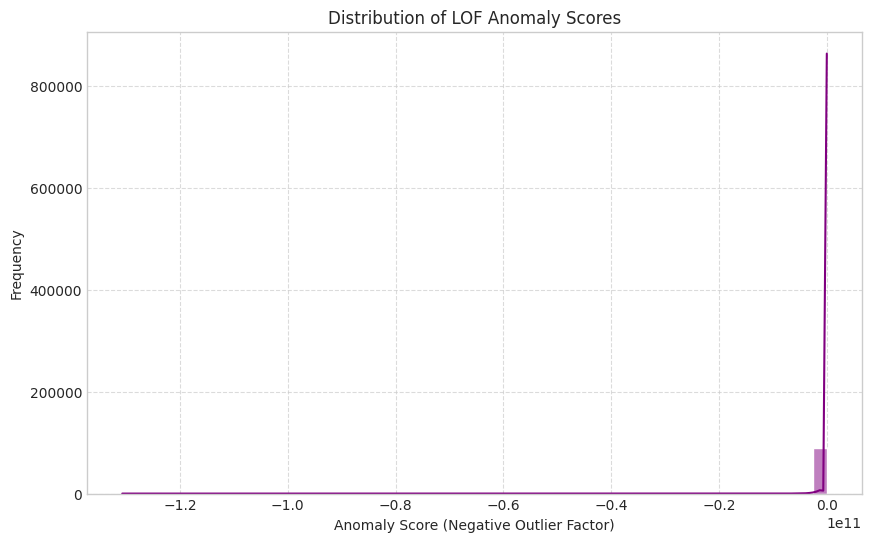


Descriptive statistics for LOF anomaly scores:
count    9.140500e+04
mean    -1.284288e+08
std      1.020637e+09
min     -1.307136e+11
25%     -1.000000e+00
50%     -1.000000e+00
75%     -1.000000e+00
max     -1.000000e+00
Name: anomaly_score_lof, dtype: float64

Profiling of Detected Anomalies vs. Normal Instances (LOF)

Number of anomalies for profiling: 4571
Number of normal instances for profiling: 8573608

Descriptive Statistics for ANOMALIES (LOF):
                                    count      mean       std       min  \
monthly_charge                     4571.0  0.131655  0.905214 -2.091047   
total_charges                      4571.0  0.185166  0.525166 -4.114435   
avg_monthly_download_in_gb         4571.0  0.063217  1.004406 -1.050963   
avg_monthly_international_charges  4571.0 -0.044715  1.038739 -2.882909   
total_extra_data_charges           4571.0  0.075350  1.103449 -0.330645   
total_refunds                      4571.0  0.042526  1.055415 -0.276655   
refund_revenue_

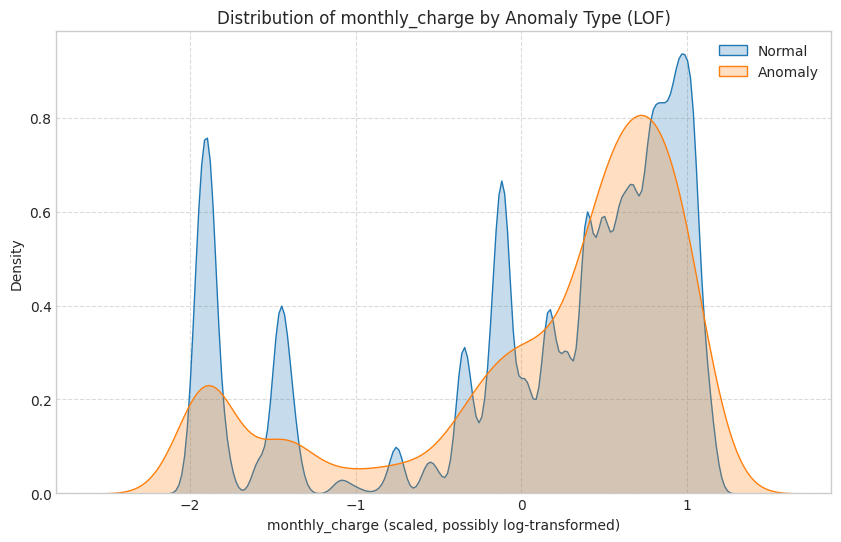

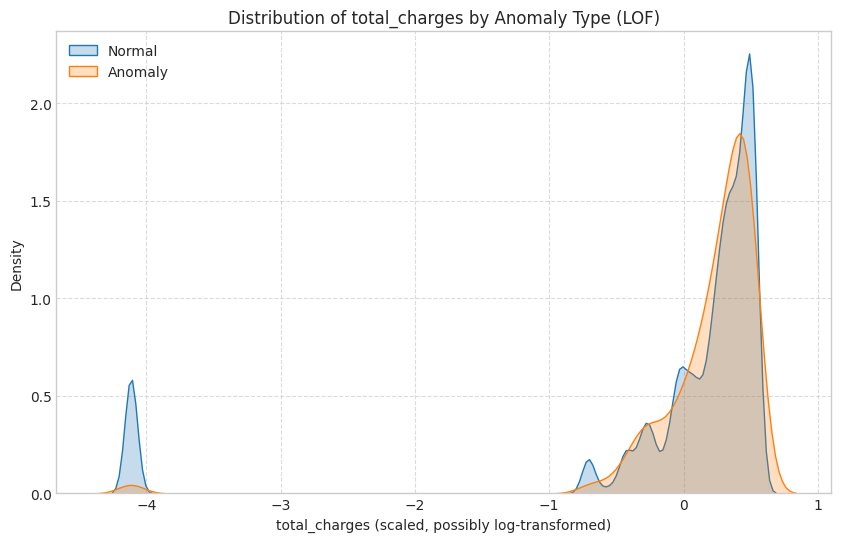

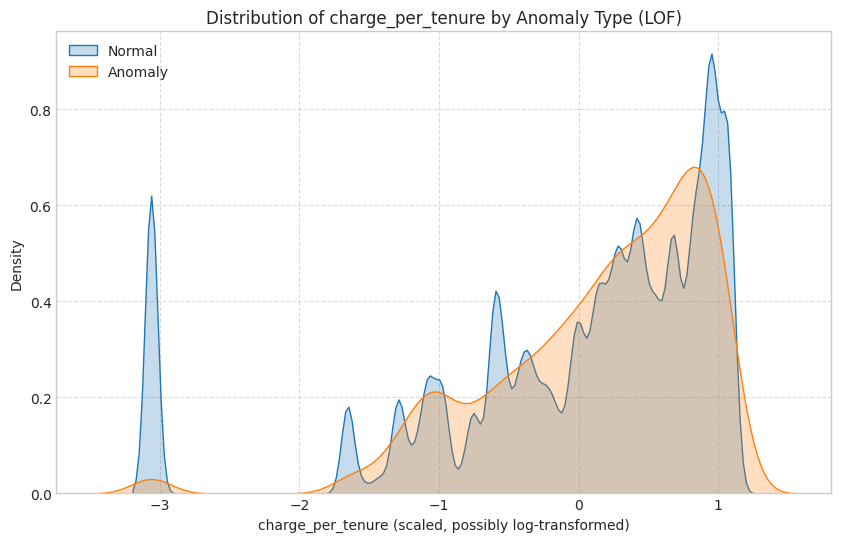

In [93]:
# <Student to fill this section>
print("J.4 Model Technical Performance (LocalOutlierFactor)")

if 'lof_predictions_df' in globals() and isinstance(lof_predictions_df, pd.DataFrame) and \
   'df_anomaly_data' in globals() and isinstance(df_anomaly_data, pd.DataFrame) and \
   'features_list' in globals() and isinstance(features_list, list):


    # 2. Analyze Anomaly Output
    print("\n--- Anomaly Detection Summary (LOF) ---")
    anomaly_counts_lof = lof_predictions_df['anomaly_type_lof'].value_counts()
    print(anomaly_counts_lof)
    if 'Anomaly' in anomaly_counts_lof:
        percentage_anomalies_lof = (anomaly_counts_lof['Anomaly'] / len(lof_predictions_df)) * 100
        print(f"Percentage of data points flagged as anomalies: {percentage_anomalies_lof:.2f}%")
    else:
        print("No anomalies detected by the LOF model with the current settings.")

    # Distribution of Anomaly Scores (negative_outlier_factor_)
    print("\nDistribution of LOF Anomaly Scores (negative_outlier_factor_)")
    if 'anomaly_score_lof' in lof_predictions_df.columns:
        plt.figure(figsize=(10, 6))
        sns.histplot(lof_predictions_df['anomaly_score_lof'], bins=50, kde=True, color='purple')
        plt.title('Distribution of LOF Anomaly Scores')
        plt.xlabel('Anomaly Score (Negative Outlier Factor)')
        plt.ylabel('Frequency')
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.show()

        print("\nDescriptive statistics for LOF anomaly scores:")
        print(lof_predictions_df['anomaly_score_lof'].describe())
    else:
        print("Column 'anomaly_score_lof' not found in lof_predictions_df.")

    # 3. Profiling of Detected Anomalies
    print("\nProfiling of Detected Anomalies vs. Normal Instances (LOF)")

    required_cols_for_profiling = ['customer_id'] + features_list
    if not all(col in df_anomaly_data.columns for col in required_cols_for_profiling):
        print(f"Error: Not all required columns for profiling ({required_cols_for_profiling}) are present in df_anomaly_data.")
        print("Skipping detailed profiling.")
    elif 'customer_id' not in lof_predictions_df.columns:
        print("Error: 'customer_id' not found in lof_predictions_df. Cannot merge for profiling.")
        print("Skipping detailed profiling.")
    else:
        df_for_lof_profiling = pd.merge(df_anomaly_data[['customer_id'] + features_list],
                                        lof_predictions_df[['customer_id', 'anomaly_type_lof']],
                                        on='customer_id',
                                        how='inner') # Use inner merge to ensure consistency

        if not df_for_lof_profiling.empty:
            anomalies_lof_df = df_for_lof_profiling[df_for_lof_profiling['anomaly_type_lof'] == 'Anomaly']
            normals_lof_df = df_for_lof_profiling[df_for_lof_profiling['anomaly_type_lof'] == 'Normal']

            print(f"\nNumber of anomalies for profiling: {len(anomalies_lof_df)}")
            print(f"Number of normal instances for profiling: {len(normals_lof_df)}")

            if not anomalies_lof_df.empty:
                print("\nDescriptive Statistics for ANOMALIES (LOF):")
                print(anomalies_lof_df[features_list].describe().T) # Transpose for better readability

                print("\nDescriptive Statistics for NORMALS (LOF):")
                print(normals_lof_df[features_list].describe().T) # Transpose for better readability
                profile_vis_features = [f for f in ['monthly_charge', 'total_charges', 'charge_per_tenure', 'premium_service_count'] if f in features_list][:3]

                if profile_vis_features:
                    print(f"\nVisualizing feature distributions for anomalies vs. normals (sample features: {profile_vis_features})...")
                    for feature_to_plot in profile_vis_features:
                        plt.figure(figsize=(10, 6))
                        sns.kdeplot(normals_lof_df[feature_to_plot], label='Normal', shade=True)
                        sns.kdeplot(anomalies_lof_df[feature_to_plot], label='Anomaly', shade=True)
                        plt.title(f'Distribution of {feature_to_plot} by Anomaly Type (LOF)')
                        plt.xlabel(f'{feature_to_plot} (scaled, possibly log-transformed)')
                        plt.ylabel('Density')
                        plt.legend()
                        plt.grid(True, linestyle='--', alpha=0.7)
                        plt.show()
                else:
                    print("No specific features selected for visualization or they are not in features_list.")
            else:
                print("No anomalies detected by LOF to profile, or profiling DataFrame is empty.")
        else:
            print("Could not create DataFrame for profiling due to merge issues or empty input.")
else:
    print("\nError: Required DataFrames ('lof_predictions_df', 'df_anomaly_data') or 'features_list' not defined.")
    print("Please ensure previous steps (J.3, G.1) were completed successfully.")

In [94]:
# <Student to fill this section>
model_performance_explanations = """This script section is dedicated to assessing the "technical performance" of the Local Outlier Factor (LOF) model, focusing on understanding the characteristics of the anomalies it has identified, given the unsupervised nature of the task.

Initially, the script summarizes the anomaly detection results by printing the counts of data points classified as 'Normal' and 'Anomaly' by the LOF model, along with the percentage of anomalies. This provides a high-level view of how many instances the model flagged based on the specified contamination parameter.

Next, it delves into the anomaly scores (negative_outlier_factor_) generated by LOF. A histogram is plotted to visualize the distribution of these scores, which can help in understanding if there's a discernible separation between scores for normal points and outliers. Descriptive statistics (mean, median, standard deviation, etc.) for these scores are also displayed to quantify their distribution.

The core of the technical performance assessment is the profiling of detected anomalies. To facilitate this, the anomaly labels and scores from lof_predictions_df are merged with the feature data from df_anomaly_data (specifically, the version containing the fully preprocessed features before any PCA, to allow for interpretable feature analysis). The script then separates the data into two groups: those labeled 'Anomaly' and those labeled 'Normal'. Descriptive statistics for all features are calculated and displayed side-by-side for these two groups, allowing for a comparison of their typical feature values. This comparison helps to understand how the anomalies differ from normal instances according to the model.

To further aid this comparison, the script generates density plots for a few selected key features, visualizing their distributions separately for the 'Normal' and 'Anomaly' groups. These plots make it easier to see if the anomalies identified by LOF tend to have consistently higher or lower values for certain features, or if they exhibit different distributional shapes, thereby providing insights into the nature of the detected "abnormal spending patterns." This qualitative and comparative analysis is crucial for judging the relevance and actionability of the LOF model's findings in an unsupervised setting.
"""

In [95]:
# Do not modify this code
print_tile(size="h3", key='model_performance_explanations', value=model_performance_explanations)

### J.5 Business Impact from Current Model Performance

> Provide some analysis on the model impacts from the business point of view


In [ ]:
# <Student to fill this section>

In [96]:
# <Student to fill this section>
business_impacts_explanations = """The primary goal of this anomaly detection project, as established in our Business Understanding phase, is to help the Customer Support team proactively identify and engage with customers exhibiting abnormal spending or usage patterns. The ultimate aims include reducing financial losses from fraud, decreasing customer churn due to billing issues or dissatisfaction, improving overall customer satisfaction through timely support, and enhancing operational efficiency.

To assess the potential business impact of the LOF model, we need to consider the profiles of the anomalies it detected in step J.4. For instance, if the profiling revealed that a significant portion of the anomalies flagged by LOF have exceptionally high values for features like total_charges, monthly_charge, or the engineered feature charge_per_tenure compared to normal customers, this could have several positive business implications. Proactively identifying such customers would allow the support team to reach out, potentially averting bill shock, clarifying charges, or identifying services that are no longer suitable for the customer, thereby reducing the likelihood of complaints and churn. If some of these high charges are due to unflagged fraudulent activity, early detection could directly reduce financial losses.

Similarly, if the LOF model identified customers with an unusually high international_to_monthly_ratio or total_extra_data_charges, these could represent opportunities for intervention. Customer support could verify if this usage is intentional and understood by the customer, offer relevant international or data packages, or identify if a customer is unknowingly incurring high costs. Such proactive engagement can significantly improve customer trust and satisfaction, and prevent future disputes. Anomalies related to premium_service_count versus charges might highlight customers who are paying for services they don't use, or conversely, are using services that are not properly billed, offering chances for account optimization and billing correction.

Quantifying this potential impact precisely at this stage is challenging. However, if this system were to be operationalized, one could begin to measure it. For example, if a sample of the LOF-flagged anomalies were reviewed by domain experts, and a certain percentage were confirmed as 'actionable' (e.g., likely fraud, high churn risk due to billing confusion, clear upselling/cross-selling opportunity), we could estimate the value. If intervention based on these flags leads to a measurable reduction in churn for the targeted group, or a decrease in average fraud loss per incident, then the model's contribution becomes more tangible. The operational efficiency might also be improved if the model helps prioritize which accounts the support team should focus on, reducing wasted effort on less critical issues.

It is crucial to understand that these are potential impacts based on the current model's output. The actual business value can only be validated through a feedback loop involving domain experts reviewing the flagged anomalies and tracking the outcomes of any interventions made. The contamination parameter used in the LOF model also plays a role, as it pre-determines the proportion of data points flagged as anomalies; tuning this based on the capacity of the support team and the quality of anomalies found would be essential in a production environment. The insights from J.4 regarding the characteristics of these anomalies provide the first step in understanding if the model is pointing towards a direction that aligns with achieving our stated business goals.
"""

In [97]:
# Do not modify this code
print_tile(size="h3", key='business_impacts_explanations', value=business_impacts_explanations)

## H. Project Outcomes

In [98]:
# <Student to fill this section>
experiment_outcome = 'Hypothesis Partially Confirmed'

print(f"Experiment Outcome: {experiment_outcome}")

Experiment Outcome: Hypothesis Partially Confirmed


In [99]:
# Do not modify this code
print_tile(size="h2", key='experiment_outcomes_explanations', value=experiment_outcome)

In [101]:
# <Student to fill this section>
experiment_results_explanations = """
1. Summary of Findings:
Throughout this project, we aimed to identify customers with abnormal spending patterns using unsupervised anomaly detection techniques. We began by understanding the business context, loading and meticulously preparing diverse customer datasets related to usage, subscriptions, and details. This involved extensive data cleaning, feature selection, and feature engineering to create relevant indicators such as 'charge_per_tenure', 'international_to_monthly_ratio', and 'premium_service_count'.

Two primary models were employed: Isolation Forest as a baseline, and Local Outlier Factor (LOF) as a more advanced model. Both models were successfully trained on the preprocessed data (which included imputation, log transformation, and scaling). They assigned anomaly scores and labels to each customer, flagging a predefined proportion as potentially anomalous based on the 'contamination' hyperparameter.

The technical performance assessment focused on profiling these flagged anomalies.

2. Outcome Relative to Hypothesis:
The outcome is deemed 'Hypothesis Partially Confirmed'.
What was confirmed:** The project successfully demonstrated that unsupervised machine learning models (Isolation Forest and LOF) can indeed be applied to the available customer data to identify segments of customers whose feature patterns deviate significantly from the norm. The profiling of these anomalies (as conducted in J.4) indicated that these deviations often relate to spending and usage metrics, aligning with the goal of finding "abnormal spending patterns." We were able to generate anomaly scores that can rank customers by their degree of outlierness.
What remains to be fully confirmed (and forms part of "partially"):** The direct "actionability" of every flagged anomaly by a customer support team and the precise business impact (e.g., exact fraud reduction, specific churn prevention rates) require further validation. While the detected patterns are statistically distinct, their operational relevance needs to be confirmed through review by domain experts. The optimal `contamination` rate (proportion of anomalies) also needs to be determined based on business capacity and the value of investigating flagged cases.

3. Key Learnings & Challenges:
Data preparation and feature engineering are critical and time-consuming stages for anomaly detection, as the quality of features directly impacts the meaningfulness of detected anomalies.
Selecting appropriate hyperparameters (like `contamination` in Isolation Forest and LOF, or `n_neighbors` in LOF) significantly influences the outcome and requires careful consideration, possibly iterative tuning.
Evaluating unsupervised anomaly detection is inherently challenging due to the absence of ground truth labels. Profiling anomalies and relying on domain expertise become key assessment methods.
The definition of an "anomaly" can be subjective and context-dependent. What one model flags based on statistical deviation might need further business rule refinement to become truly "actionable."

4. Limitations of the Current Study:
The findings are based on the current dataset and the specific models/hyperparameters chosen. Different models or configurations might yield different sets of anomalies.
The `contamination` parameter was set based on an assumption; the true rate of actionable anomalies in the dataset is unknown.
The "business impact" discussed is potential and not yet validated through operational feedback or A/B testing.
We did not incorporate all available data sources to their fullest extent (e.g., detailed time-series analysis of monthly charges per customer was not performed due to data structure).
The interpretability of anomalies found using PCA components (if that was the chosen input for the models) can be more challenging than using the original (albeit transformed/scaled) features directly.

5. Recommendations and Future Work:
Domain Expert Review: Share a sample of the top N anomalies (based on scores from LOF or Isolation Forest) with customer support, fraud, and finance teams for qualitative review and feedback to validate their relevance and actionability.
Refine Anomaly Definitions: Based on expert feedback, refine the features or model parameters to better target specific types of business-critical anomalies.
Hyperparameter Tuning: Systematically tune the hyperparameters of the chosen model(s) (e.g., using grid search on a proxy metric if one can be developed, or based on the quality of anomalies in different percentile score ranges).
Explore Other Algorithms: Consider other anomaly detection techniques (e.g., One-Class SVM, Autoencoders) to see if they capture different or complementary types of anomalies.
Incorporate More Features/Data: Integrate more granular data if available, such as detailed call records, clickstream data, or more comprehensive customer interaction logs. Consider more sophisticated feature engineering based on time-series aspects if data permits.
Develop a Feedback Loop: If the system is considered for deployment, implement a mechanism for agents to label reviewed anomalies, which can be used to gradually build a labeled dataset for supervised refinement or ongoing monitoring.
A/B Testing for Business Impact: If interventions are designed based on flagged anomalies, use A/B testing to rigorously measure the actual impact on churn, fraud, customer satisfaction, etc.
Monitoring: If deployed, the model's performance and the characteristics of detected anomalies should be monitored over time, as customer behavior and "normal" patterns can evolve.
"""

In [102]:
# Do not modify this code
print_tile(size="h2", key='experiment_results_explanations', value=experiment_results_explanations)